# WT and AA windows, and visible EFA component curves

These figures are embedded so no external image loading is required. Frame numbering is zero-based. WT windows: 150–159, 160–169, 170–179, 180–189. AA windows: 160–169, 170–179, 180–189, 190–199. Same ten-frame lengths, baseline anchors and propagation as documented in the comparison scripts. The shared extended fit interval is 0.012–0.055 Å^-1.

| WT window | Conventional Rg (Å) | Extended Rg (Å) |
|---|---:|---:|
| Leading | 33.82 | 29.80 |
| Center | 28.57 | 27.20 |
| Trailing | 28.86 | 27.20 |
| Late tail | 32.41 | 27.74 |

The leading-minus-center extended Rg has a conditional paired 95% interval of +1.25 to +3.75 Å (300 perturbations). The difference remains positive in pre-only and post-only checks, with the latter marginal. Leading versus center shape discrepancy chi-square/dof=3.39 versus 0.91 for trailing and 0.67 for tail. The tail is weak and background sensitive. No component identity is established.

The WT shoulder EFA curve is positive and structured, unlike AA's secondary curve. The exploratory extended fit is 40.9 Å with qmax Rg<2, but reduced chi-square=2.44 and qmin sensitivity gives 37.6–43.3 Å. Its single-chain 120-residue assumption is unverified; no oligomer stoichiometry follows. Error bars for secondary curves condition on fixed elution coefficients, whereas main-component errors are bootstrap estimates. Curve intensity scales are arbitrary and not directly comparable as populations. Negative AA intensities remain visible on a symmetric-log axis.

Recreate figures with `component_visibility/plot_components.py`; reproduce direct-window results with the two `compare_windows.py` scripts. They currently reference the original Desktop source HDF5 paths; edit SOURCE for another checkout. The Rg model implementation is included beside each script.


**Provenance correction (22 September):** Natalie’s notebooks perform buffer subtraction on the HDF5 input profiles. Both AA_082024.ipynb and AA_052026.ipynb load AA_052026.hdf5 and report buffer frames24–70; the primary WT analysis reports220–236. Earlier claims that the needed pre-subtraction profiles were absent, or that our HDF5-based subtraction was necessarily only a residual correction, were incorrect. The HDF5-based calculations already read `profiles` and subtract their chosen buffer once, so this correction does not itself change their numerical output. Original exported DAT curves are a later processing stage and must not be subtracted again. The new controlled test is in [09_buffer_window_sensitivity.ipynb](09_buffer_window_sensitivity.ipynb).

## What do pre, linear and post mean?
These are **three alternative buffer/background subtractions**, applied to the input curves before fitting. They are not EFA components, different polymer models, or three measured protein states. The HDF5 input profiles precede Natalie’s notebook buffer subtraction. Candidate buffer anchors still require validation as sample-free regions.

| Sample | Pre anchor frames | Post anchor frames |
|---|---|---|
| WT |55–94|210–234|
| AA |35–74|225–254|

For each q, average the pre-anchor frames to get $B_{pre}(q)$, and the post-anchor frames to get $B_{post}(q)$. Each is an entire q-dependent curve, not a single constant offset. For a protein frame t, subtract:

$$\widehat B(q,t)=\begin{cases}B_{pre}(q)&\text{pre}\\B_{post}(q)&\text{post}\\(1-f_t)B_{pre}(q)+f_tB_{post}(q)&\text{linear}\end{cases}$$

where $f_t=(t-t_{pre})/(t_{post}-t_{pre})$, clipped to [0,1], and the anchor times are the midpoints of their frame ranges. The three corrected estimates are $I(q,t)=Y(q,t)-\widehat B(q,t)$, then averaged over the selected protein window.

If the true signal is $Y(q,t)=c_tP(q)+B(q,t)$, a baseline error leaves $\widehat I=c_tP+\delta B$. Its relative effect is $\delta B/(c_tP)$: it grows as the protein signal falls on the peak edges. Because Rg comes from the low-q slope, $R_g^2=-3\,d\ln I/d(q^2)$ at q approaching0, a q-dependent residual background changes Rg, not just intensity. Extended Guinier accounts for polymer curvature but cannot fix an incorrect subtraction.

**Read the bottom-right panels with their different y-axis scales in mind.** WT spans roughly26–33Å; AA spans only31.6–32.3Å. The WT pre-corrected leading/tail can resemble AA, but the WT center does not:

| Window | WT pre / linear / post Rg (Å) | AA pre / linear / post Rg (Å) |
|---|---|---|
| Leading |31.86 /29.80 /27.94|32.11 /31.80 /31.57|
| Center |28.17 /27.20 /26.56|32.31 /32.20 /32.14|
| Trailing |28.75 /27.20 /26.42|32.10 /31.96 /31.90|
| Late tail |32.77 /27.74 /25.79|32.23 /31.87 /31.75|

These values use extended fits over the same0.012–0.055Å⁻¹ range. WT windows are150–159/160–169/170–179/180–189; AA windows are160–169/170–179/180–189/190–199. They are direct averages, not EFA-purified profiles. The newer five-frame leading-edge test (WT161–165;AA165–169) is a separate selection.

The top-right and bottom-left panels of the original four-panel window plots use the **linear** baseline only. Their shape normalization is multiplicative; it does not change Rg. WT's leading window also overlaps the earlier shoulder and shows structured shape residuals. Its late tail is weaker and particularly baseline-sensitive. Neither observation assigns an oligomer.

These tested corrections preserve a smaller WT center than AA center, while leaving uncertainty in the absolute size and edge estimates. This does not validate linear subtraction as the true baseline: anchor quality, residual time dependence, and original sample/buffer exports must decide the background model—not which model produces the preferred Rg. The spread is systematic sensitivity, not a statistical confidence interval.

The existing anchor stationarity screen passes WT55–94 (maximum band slope magnitude2.97 standard errors; half-window profile discrepancy0.59 in its mean-square metric) and WT210–234 (1.45 and0.71). These tests assess time stability, not absence of protein. The pre anchor is low and flat on the full trace; the post anchor is elevated. The reason for that difference remains unresolved.


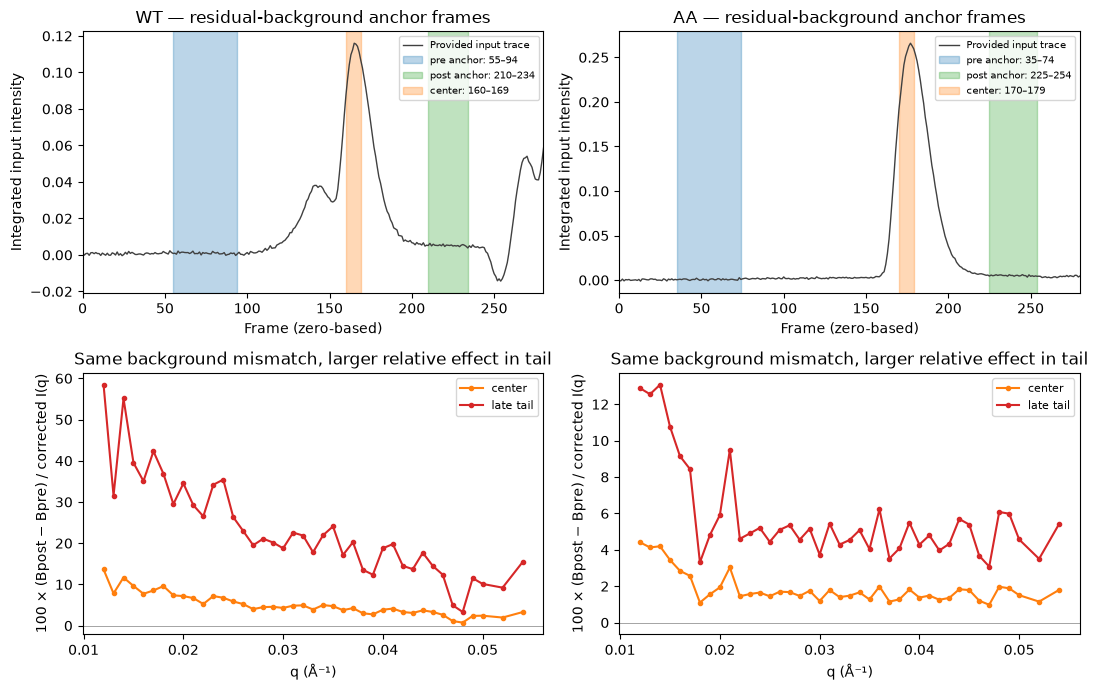

In [1]:
from pathlib import Path
import sys
from IPython.display import display
ROOT=Path.cwd();sys.path.insert(0,str(ROOT/'analysis'))
from explain_baseline_windows import plot_baseline_anchors
import matplotlib.pyplot as plt
%matplotlib inline
fig=plot_baseline_anchors();display(fig);plt.close(fig)


## WT shoulder I(q)

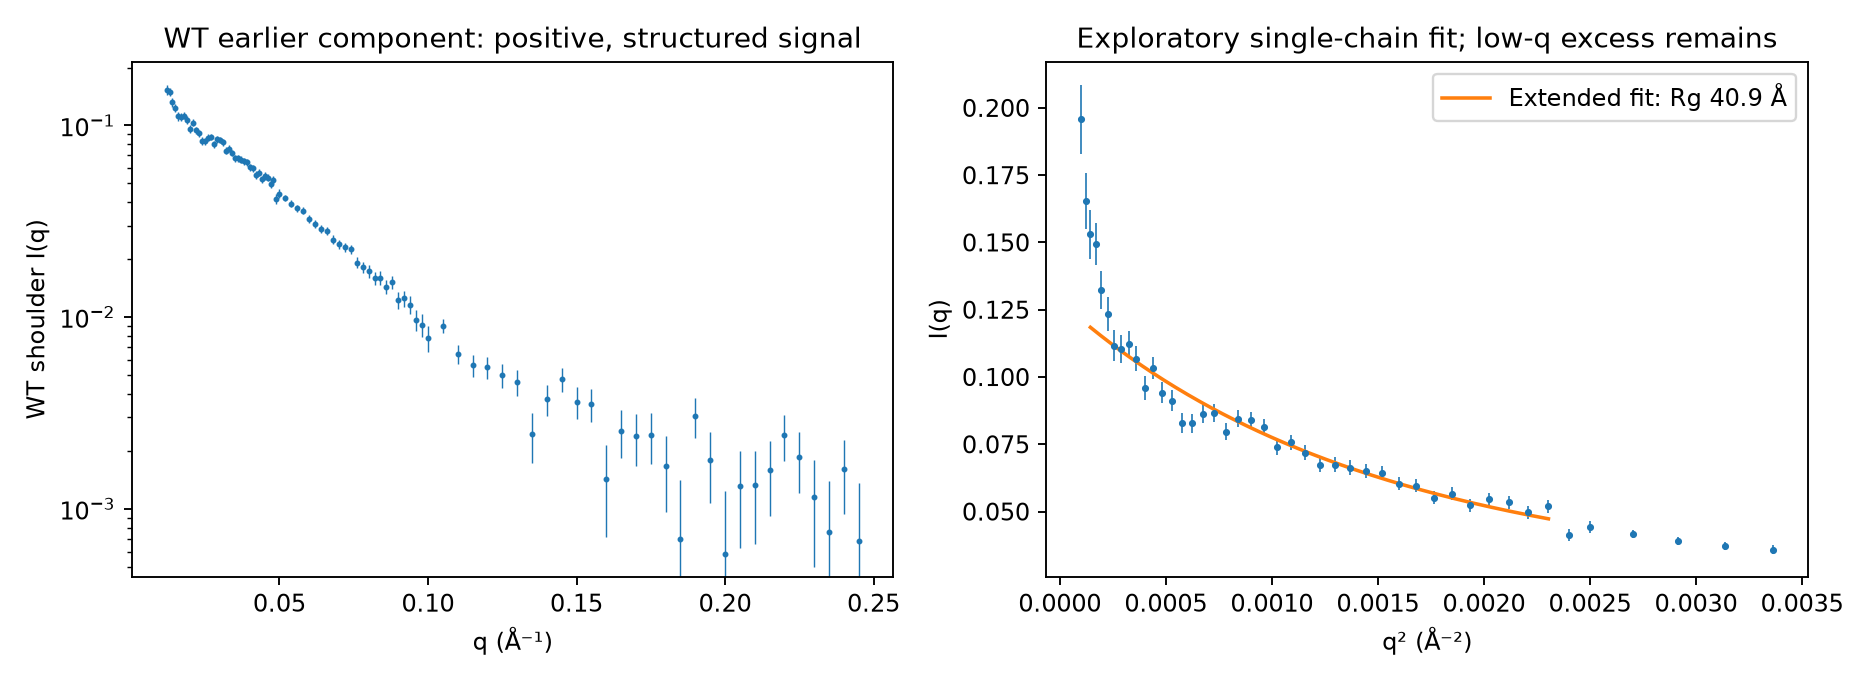

### I(q) first, with conventional and extended Guinier side by side
These executable comparisons use the same exported curves and propagated errors. Fit ranges and conditional uncertainties are shown explicitly. The additional matched-range extended column separates model-form effects from q-range effects. See notebook07 for paired differences and full uncertainty assumptions.

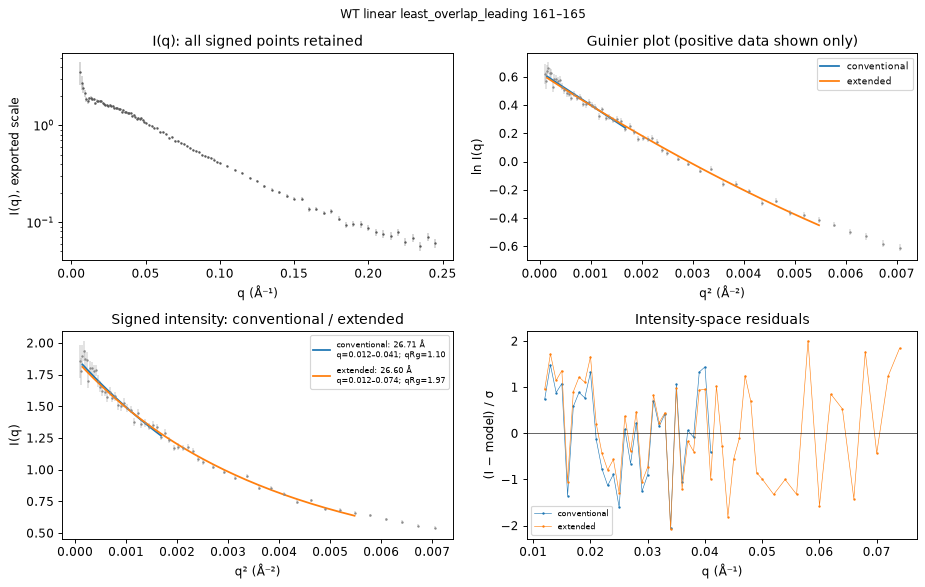

Component identity and physical validity are not established by a converged fit.

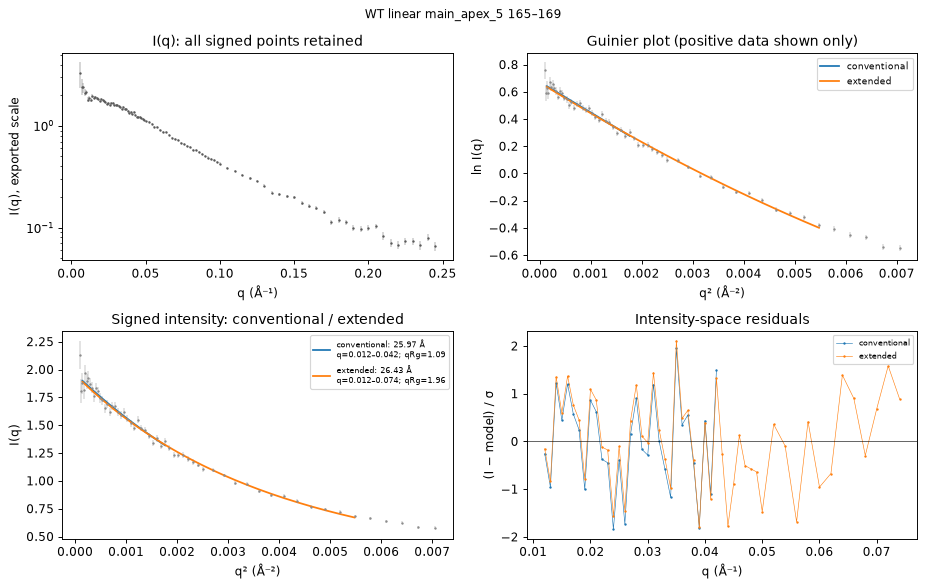

Component identity and physical validity are not established by a converged fit.

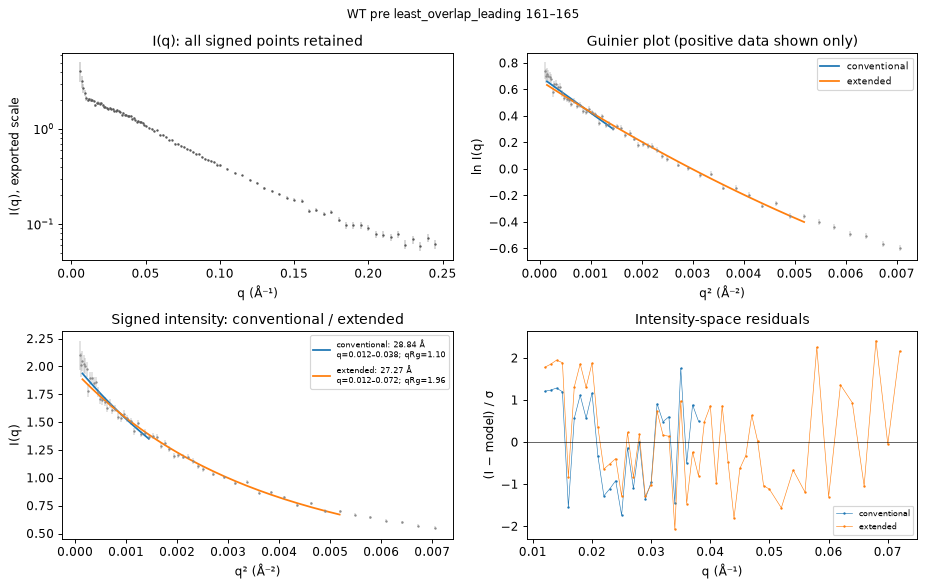

Component identity and physical validity are not established by a converged fit.

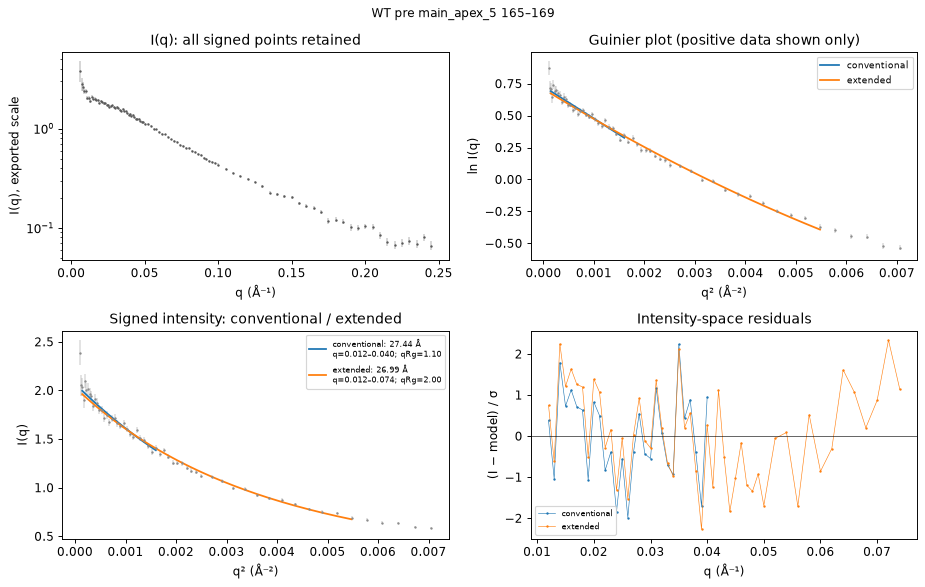

Component identity and physical validity are not established by a converged fit.

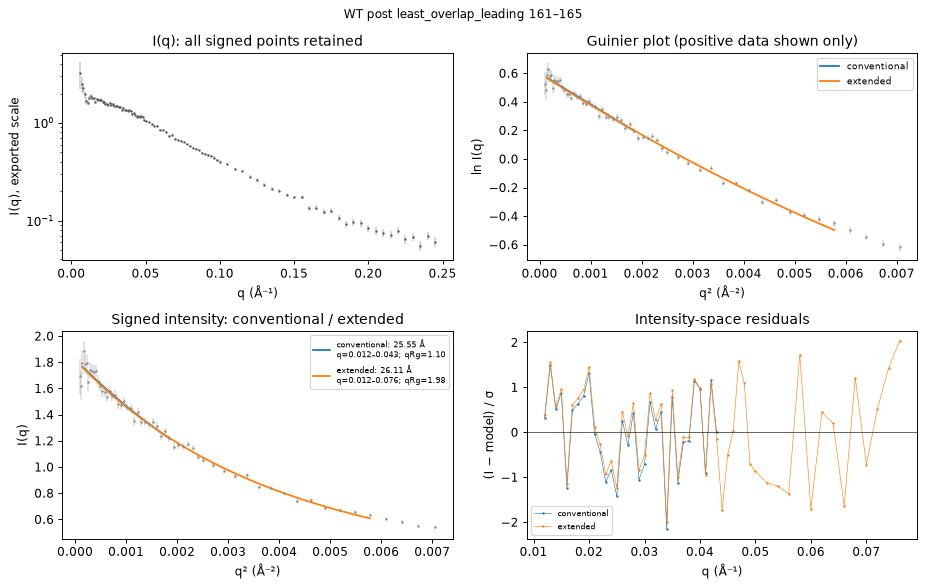

Component identity and physical validity are not established by a converged fit.

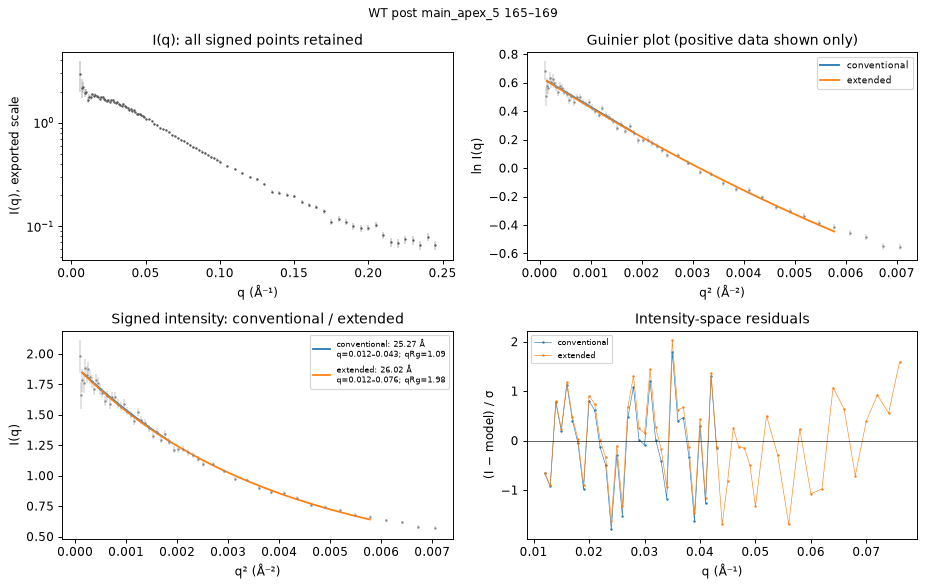

Component identity and physical validity are not established by a converged fit.

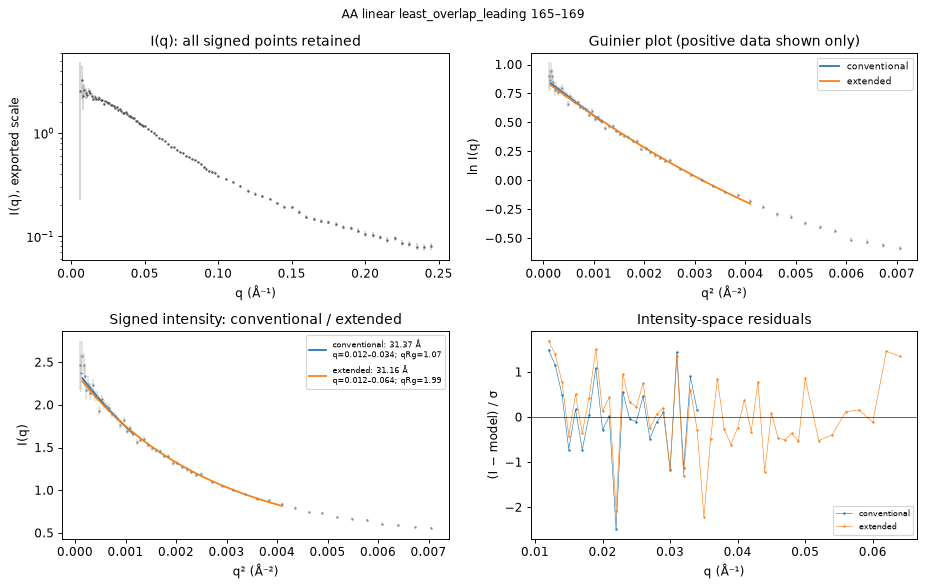

Component identity and physical validity are not established by a converged fit.

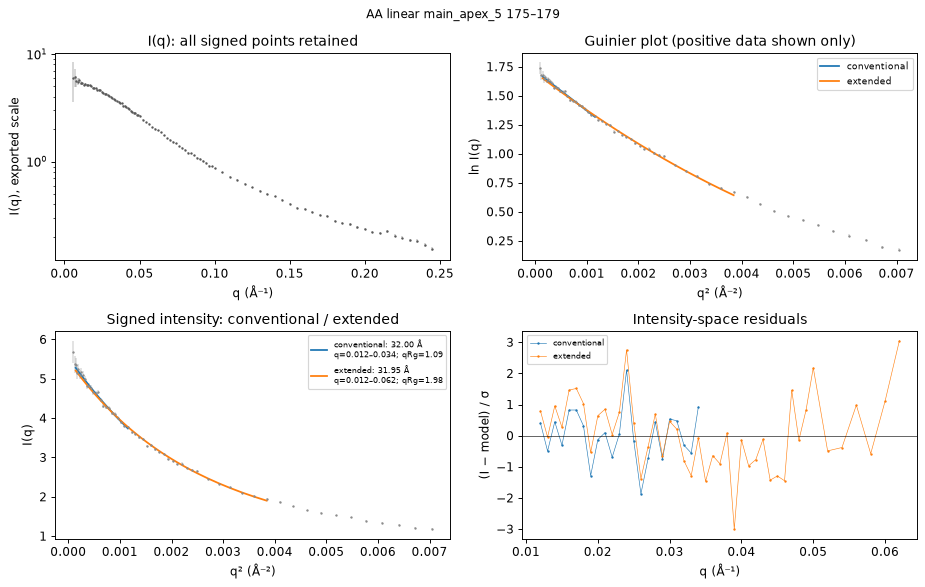

Component identity and physical validity are not established by a converged fit.

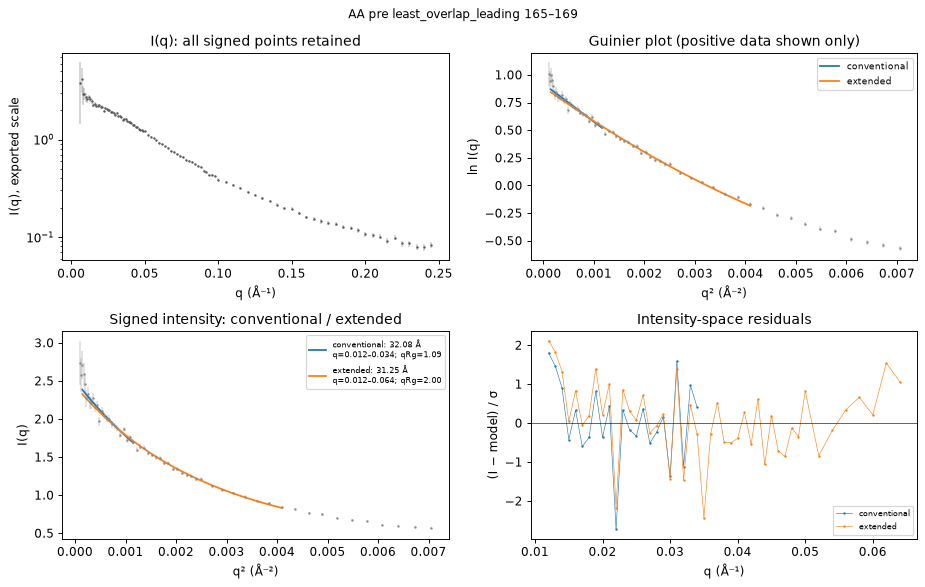

Component identity and physical validity are not established by a converged fit.

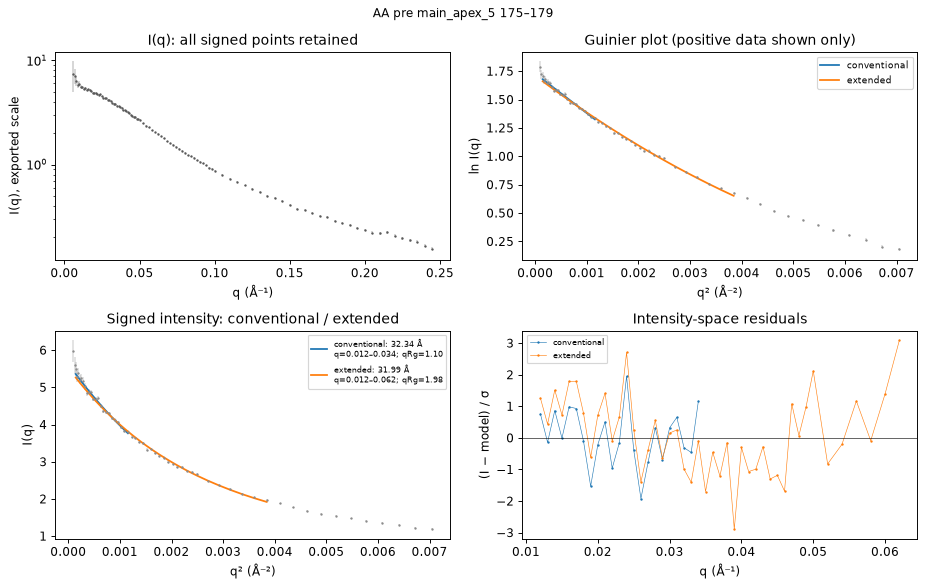

Component identity and physical validity are not established by a converged fit.

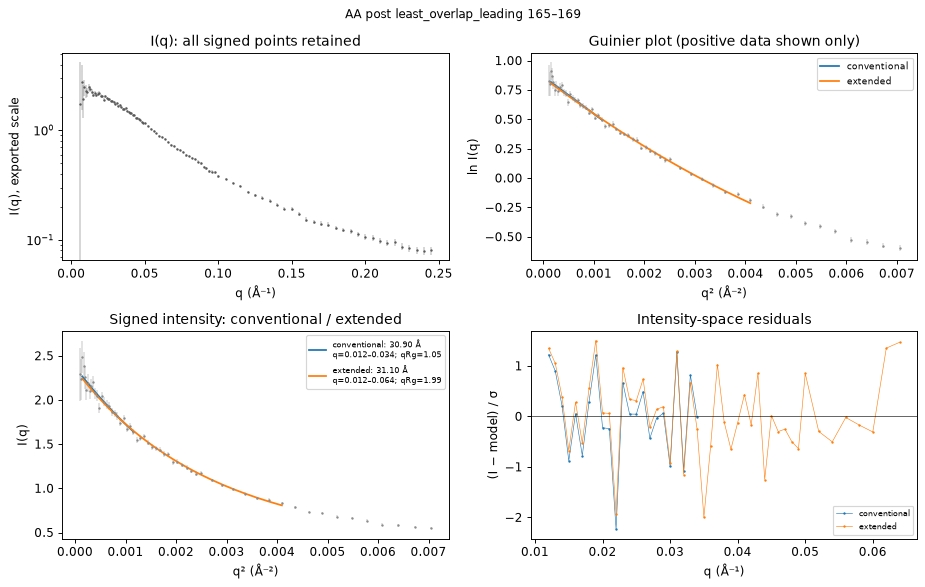

Component identity and physical validity are not established by a converged fit.

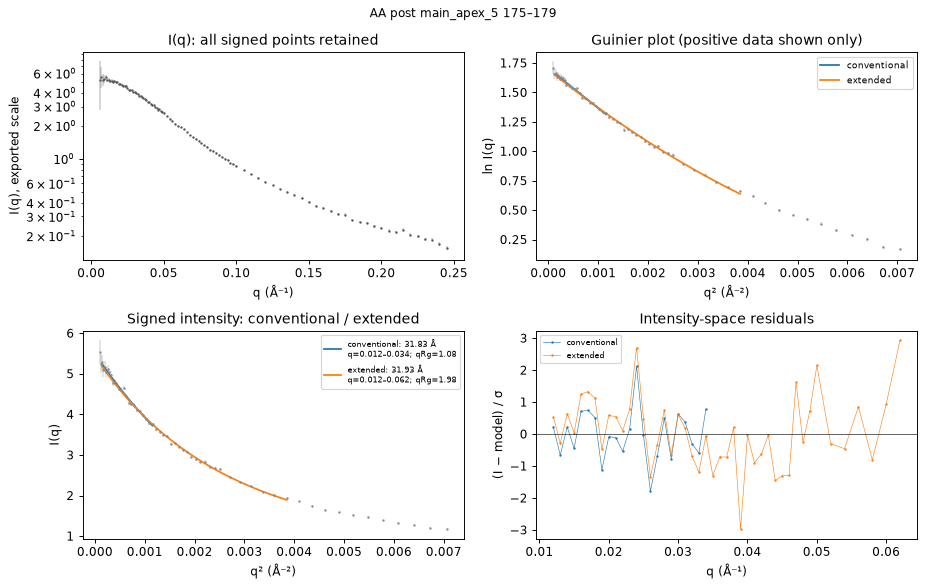

Component identity and physical validity are not established by a converged fit.

| Curve | Conventional Rg ± SE (Å) | Extended, same q range | Extended, qRg≤2 | Conditional extended 95% |
|---|---:|---:|---:|---|
|WT linear least_overlap_leading 161–165|26.71 ± 0.57|27.60 ± 0.65|26.60 ± 0.19|[26.26, 26.97]|
|WT linear main_apex_5 165–169|25.97 ± 0.52|26.79 ± 0.60|26.43 ± 0.18|[26.11, 26.79]|
|WT pre least_overlap_leading 161–165|28.84 ± 0.65|29.88 ± 0.76|27.27 ± 0.20|[26.89, 27.63]|
|WT pre main_apex_5 165–169|27.44 ± 0.56|28.37 ± 0.65|26.99 ± 0.18|[26.66, 27.35]|
|WT post least_overlap_leading 161–165|25.55 ± 0.54|26.35 ± 0.62|26.11 ± 0.19|[25.77, 26.5]|
|WT post main_apex_5 165–169|25.27 ± 0.53|26.02 ± 0.60|26.02 ± 0.18|[25.69, 26.38]|
|AA linear least_overlap_leading 165–169|31.37 ± 0.95|32.54 ± 1.12|31.16 ± 0.27|[30.65, 31.64]|
|AA linear main_apex_5 175–179|32.00 ± 0.45|33.34 ± 0.53|31.95 ± 0.14|[31.68, 32.23]|
|AA pre least_overlap_leading 165–169|32.08 ± 0.92|33.37 ± 1.10|31.25 ± 0.27|[30.74, 31.74]|
|AA pre main_apex_5 175–179|32.34 ± 0.45|33.74 ± 0.53|31.99 ± 0.14|[31.72, 32.26]|
|AA post least_overlap_leading 165–169|30.90 ± 1.02|31.98 ± 1.18|31.10 ± 0.28|[30.57, 31.6]|
|AA post main_apex_5 175–179|31.83 ± 0.47|33.13 ± 0.55|31.93 ± 0.14|[31.66, 32.21]|


In [1]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis/compare_all_iq.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from compare_all_iq import *
%matplotlib inline

_all=json.loads((OUT/'fit_results.json').read_text())
comparison_rows=gallery(_all,['EFA-guided direct edges'])

## All EFA components

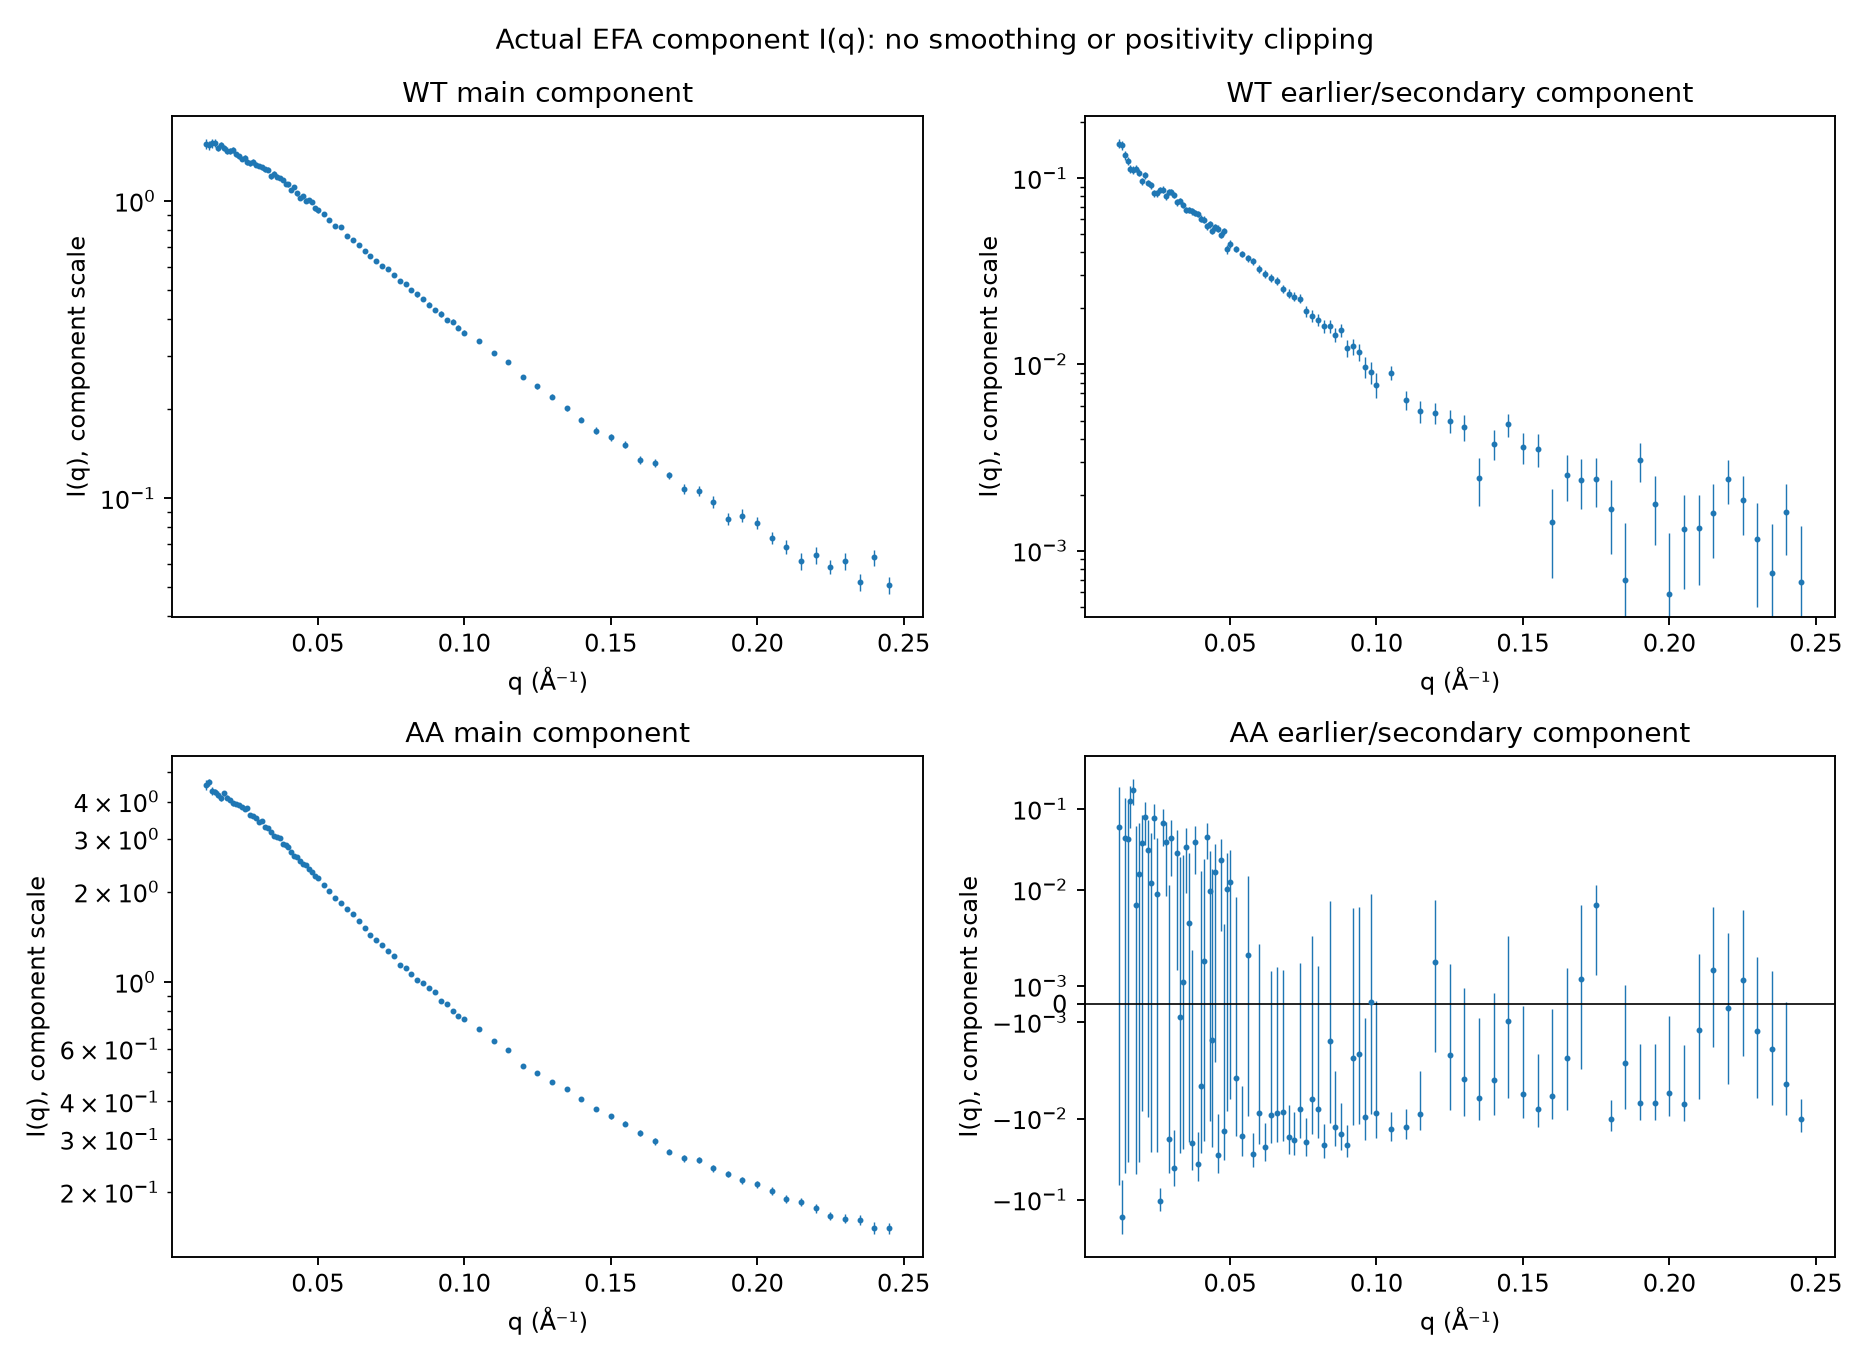

## WT direct-window comparison

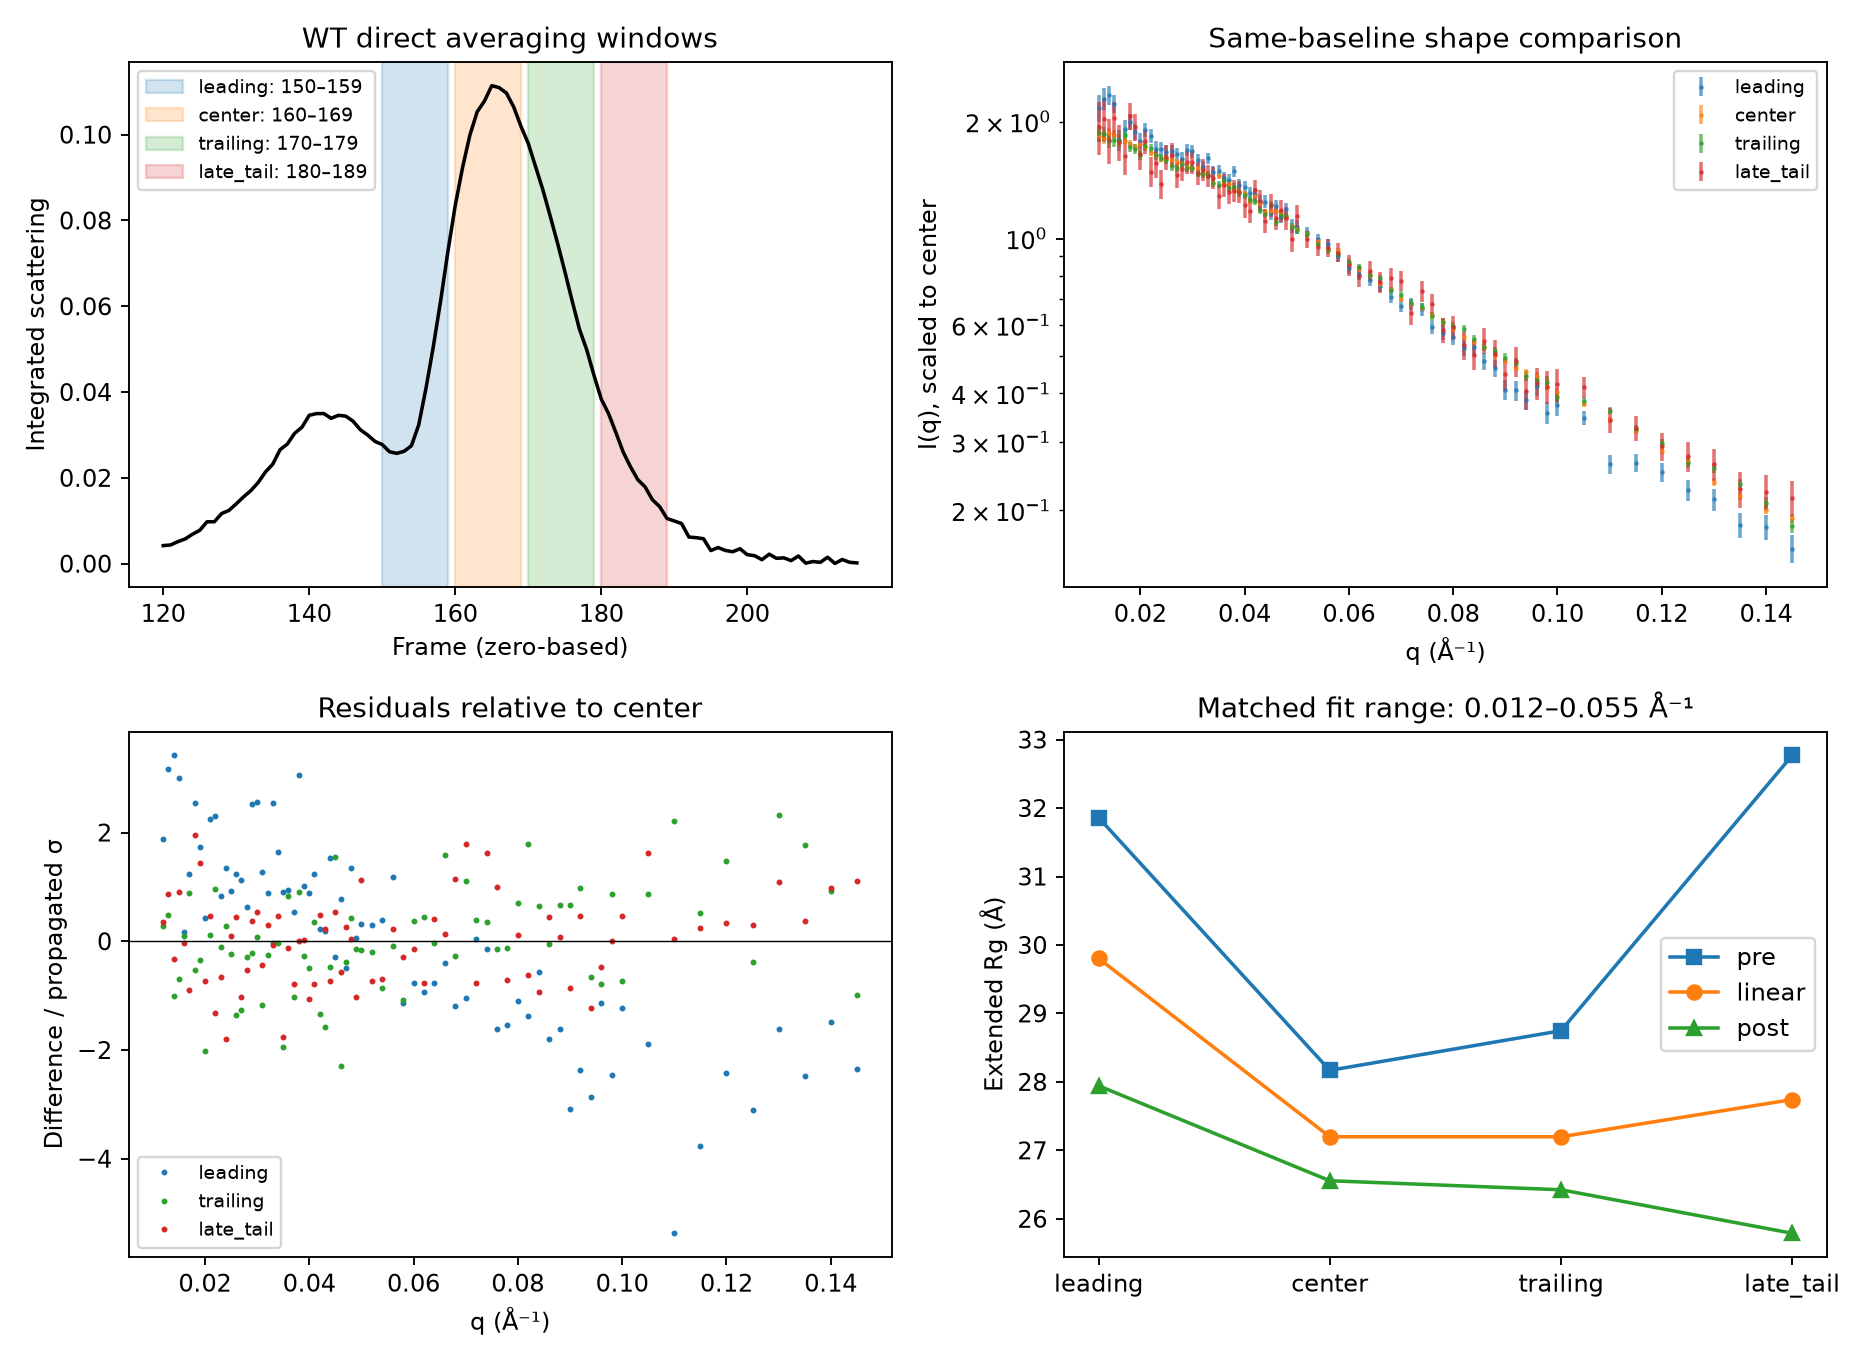

## AA direct-window comparison

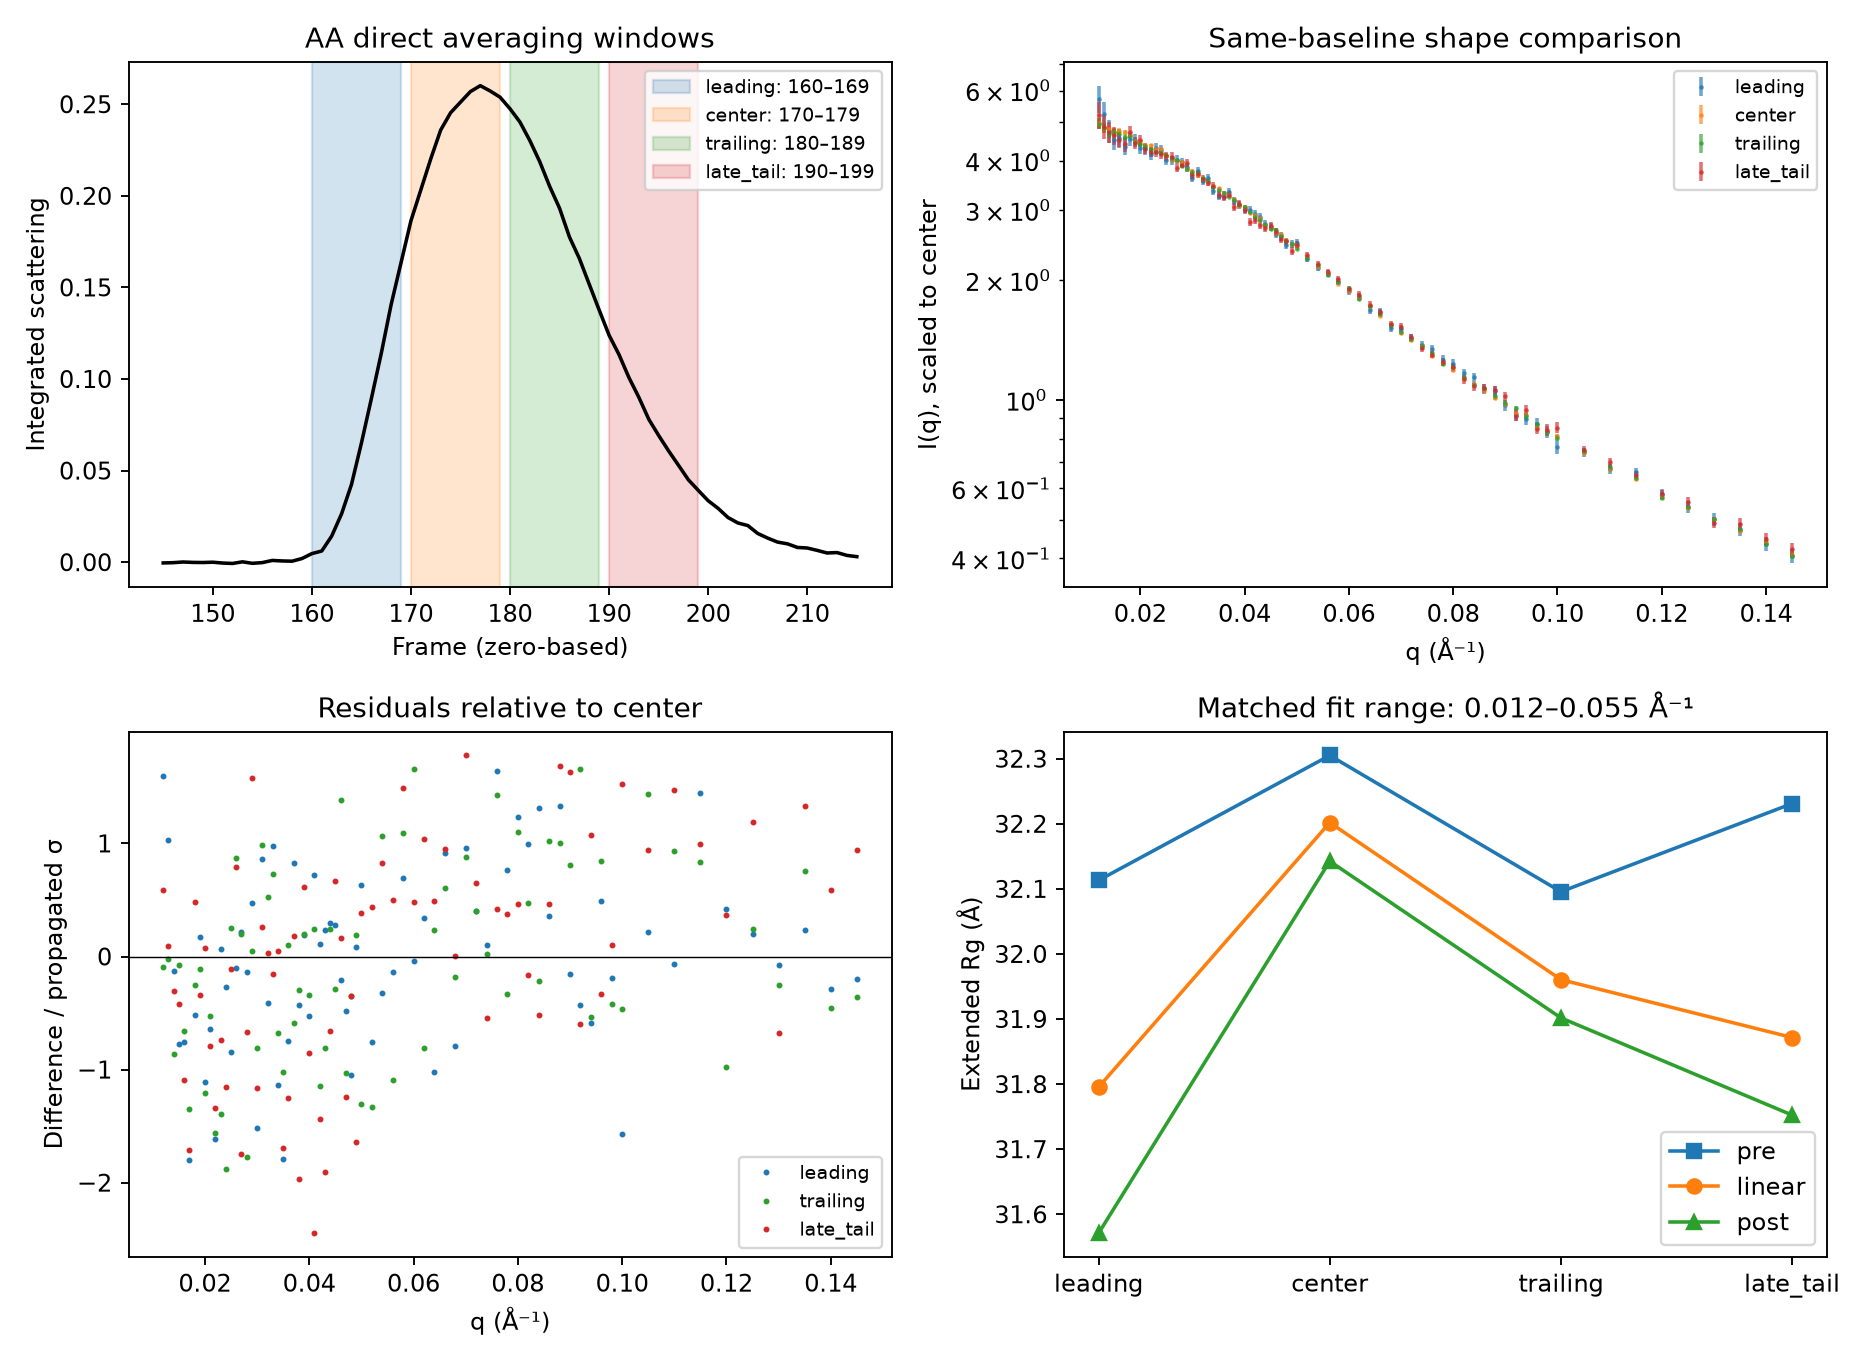

### I(q) first, with conventional and extended Guinier side by side
These executable comparisons use the same exported curves and propagated errors. Fit ranges and conditional uncertainties are shown explicitly. The additional matched-range extended column separates model-form effects from q-range effects. See notebook07 for paired differences and full uncertainty assumptions.

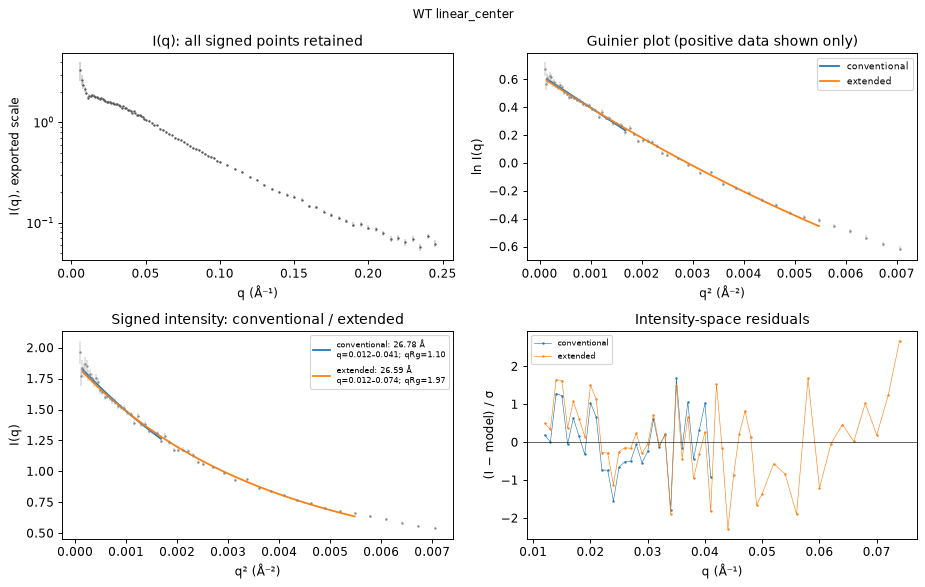

Component identity and physical validity are not established by a converged fit.

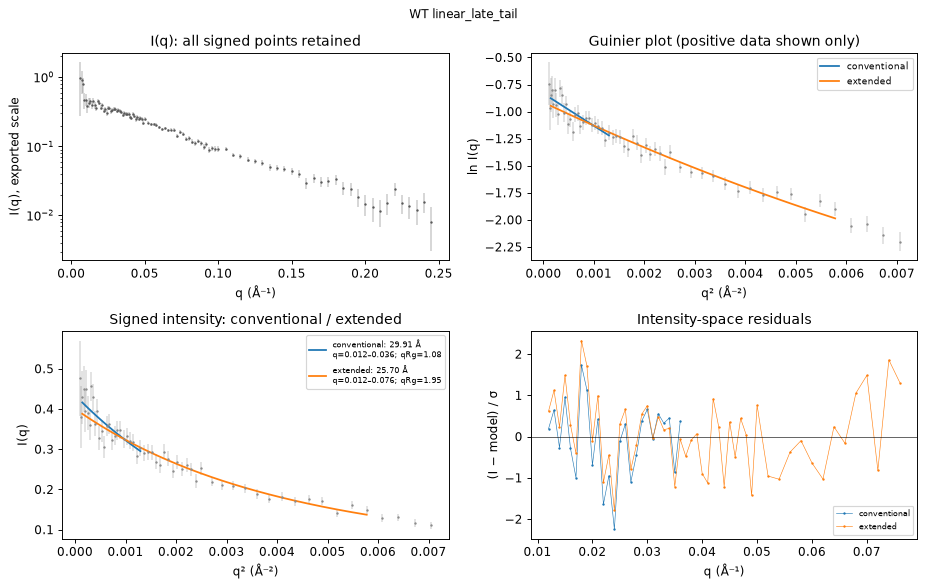

Component identity and physical validity are not established by a converged fit.

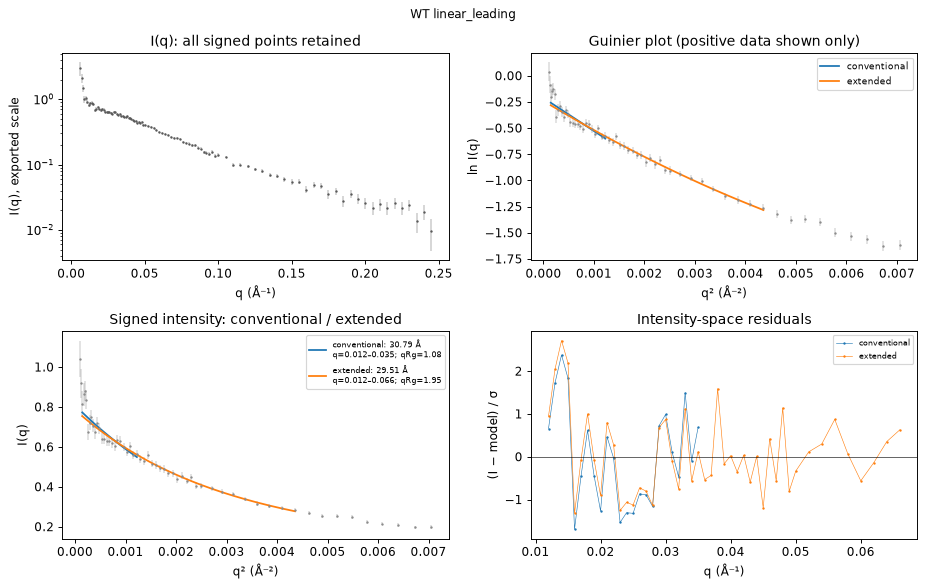

Component identity and physical validity are not established by a converged fit.

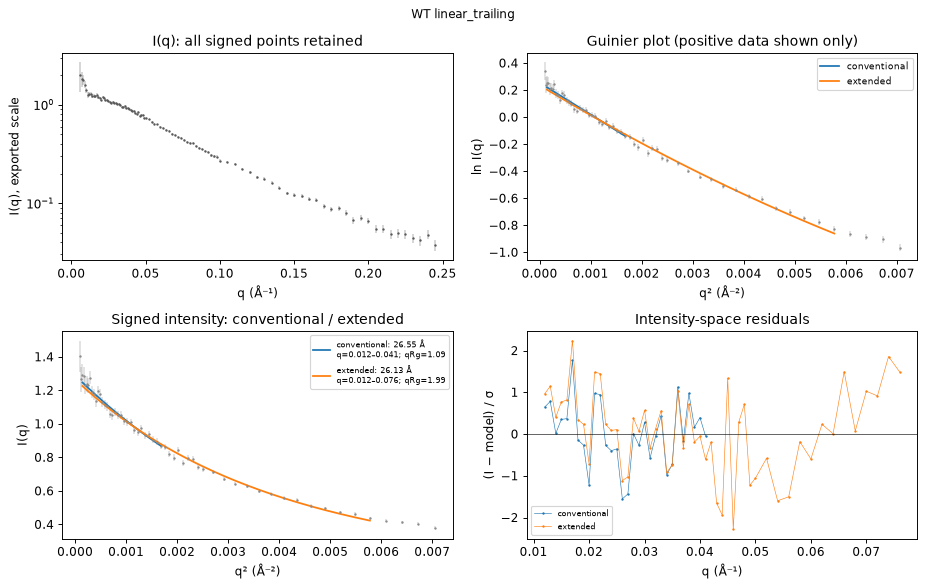

Component identity and physical validity are not established by a converged fit.

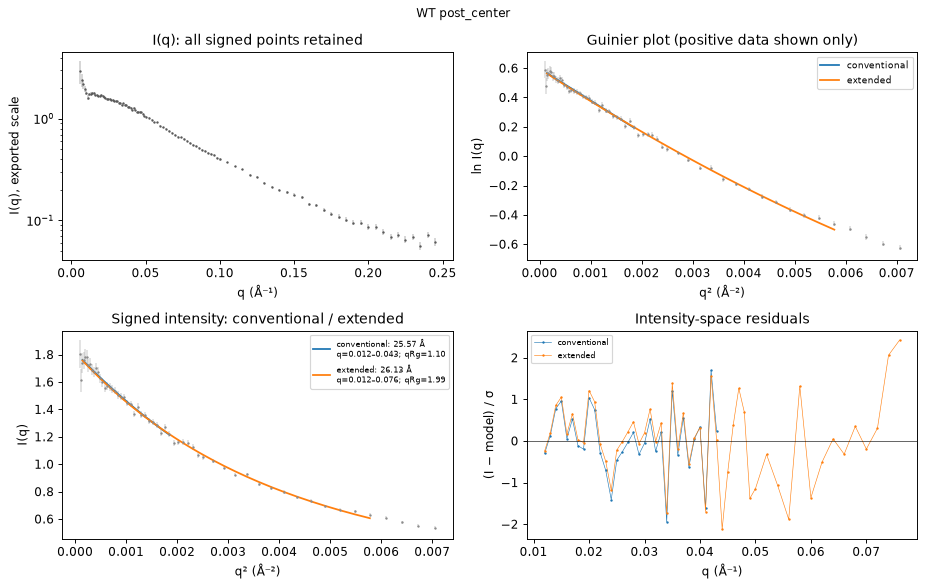

Component identity and physical validity are not established by a converged fit.

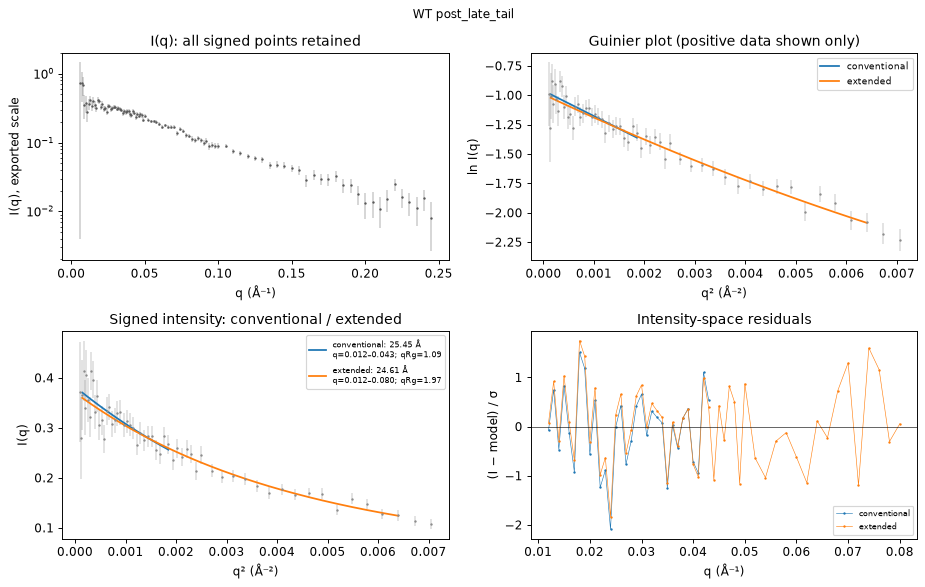

Component identity and physical validity are not established by a converged fit.

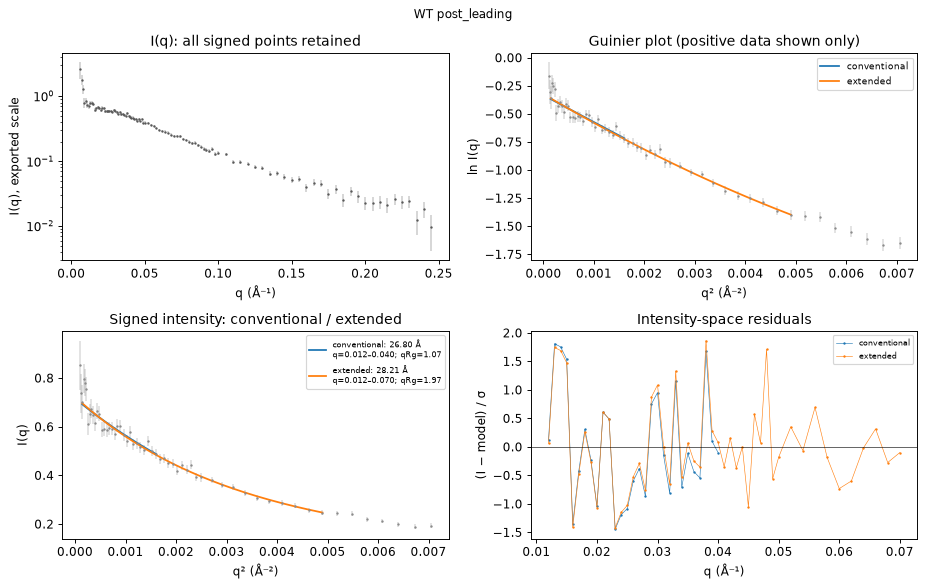

Component identity and physical validity are not established by a converged fit.

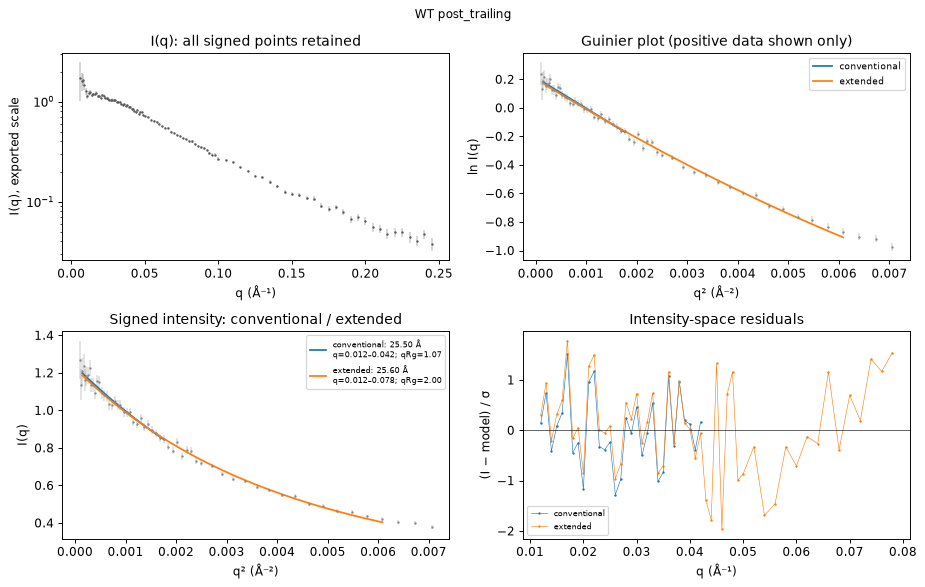

Component identity and physical validity are not established by a converged fit.

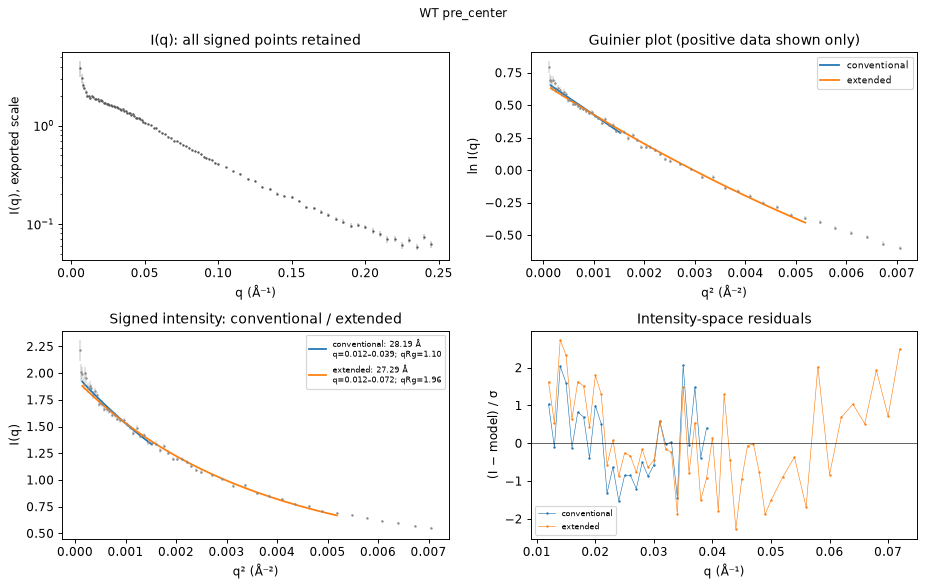

Component identity and physical validity are not established by a converged fit.

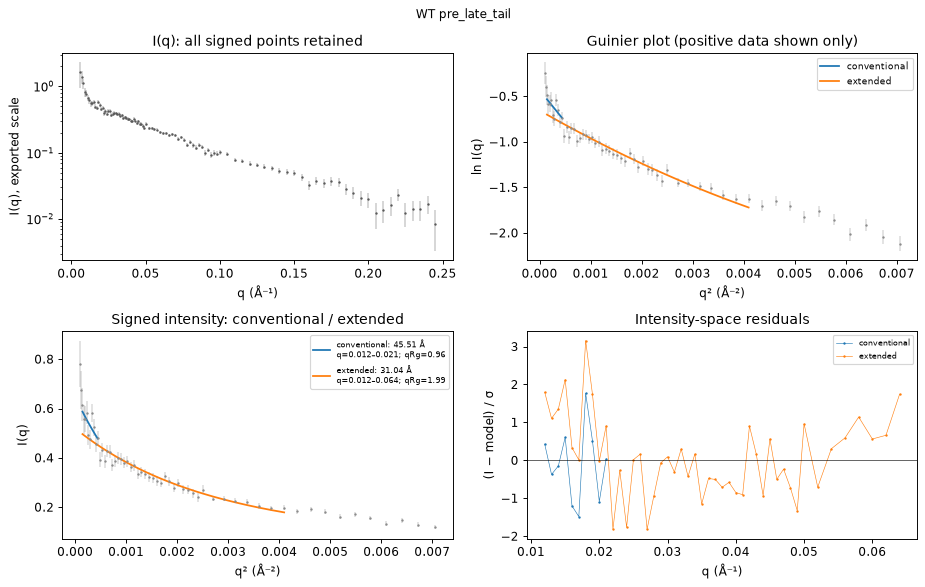

Component identity and physical validity are not established by a converged fit.

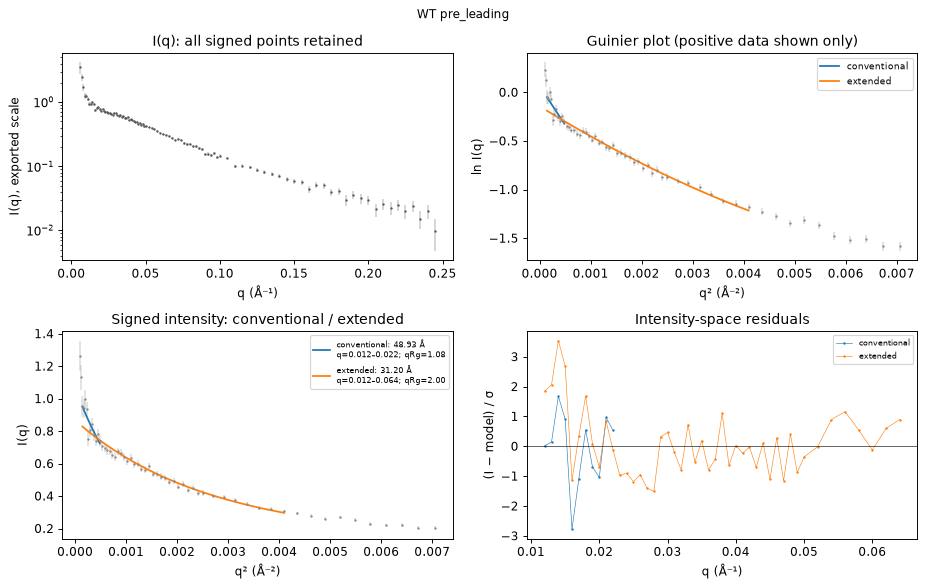

Component identity and physical validity are not established by a converged fit.

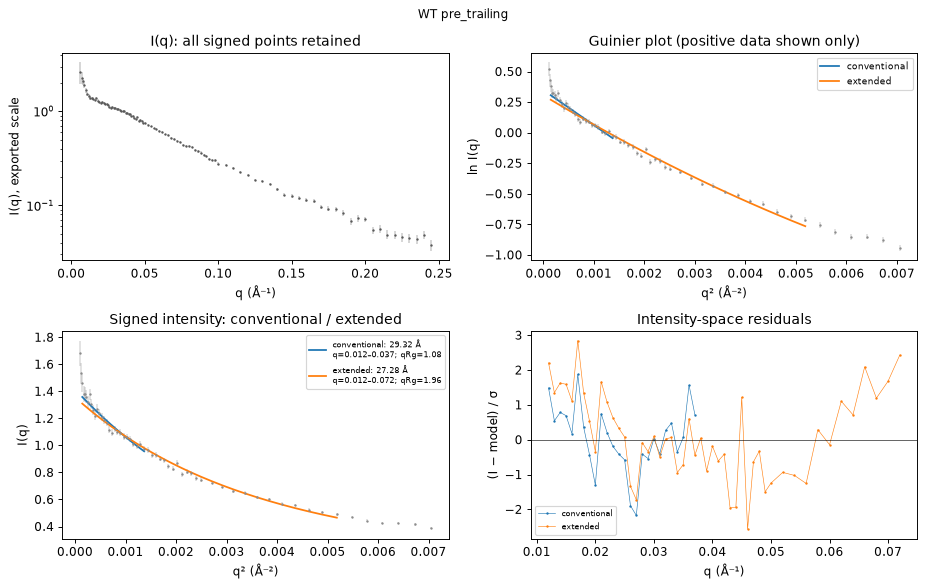

Component identity and physical validity are not established by a converged fit.

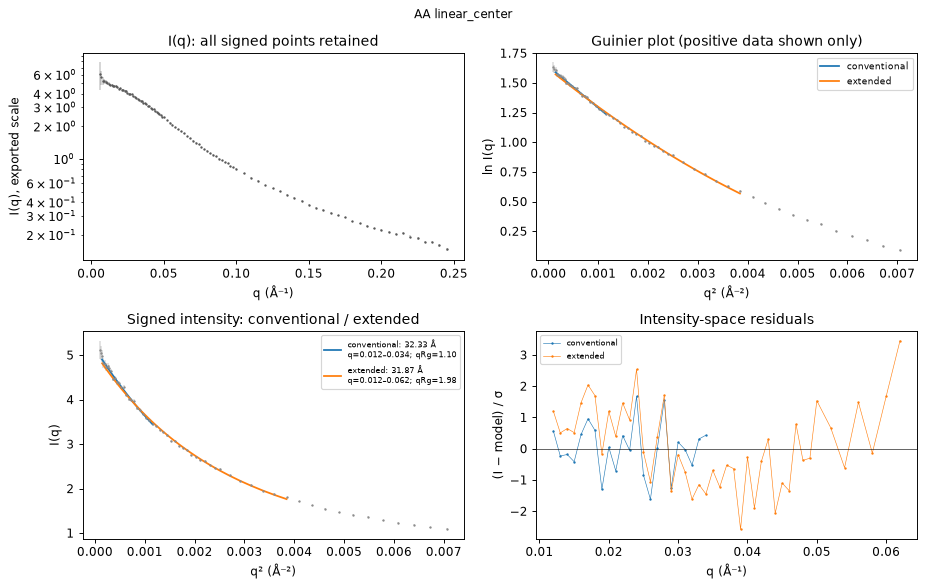

Component identity and physical validity are not established by a converged fit.

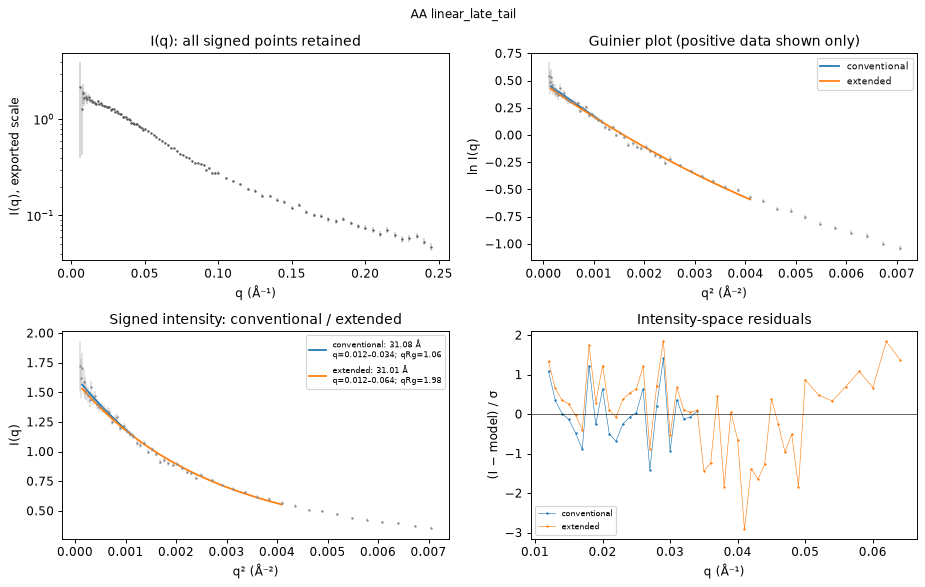

Component identity and physical validity are not established by a converged fit.

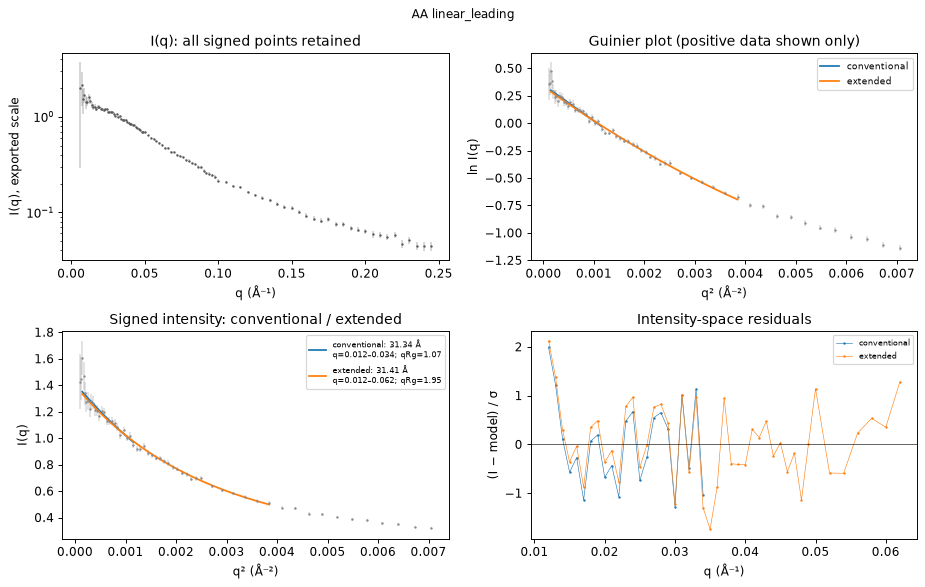

Component identity and physical validity are not established by a converged fit.

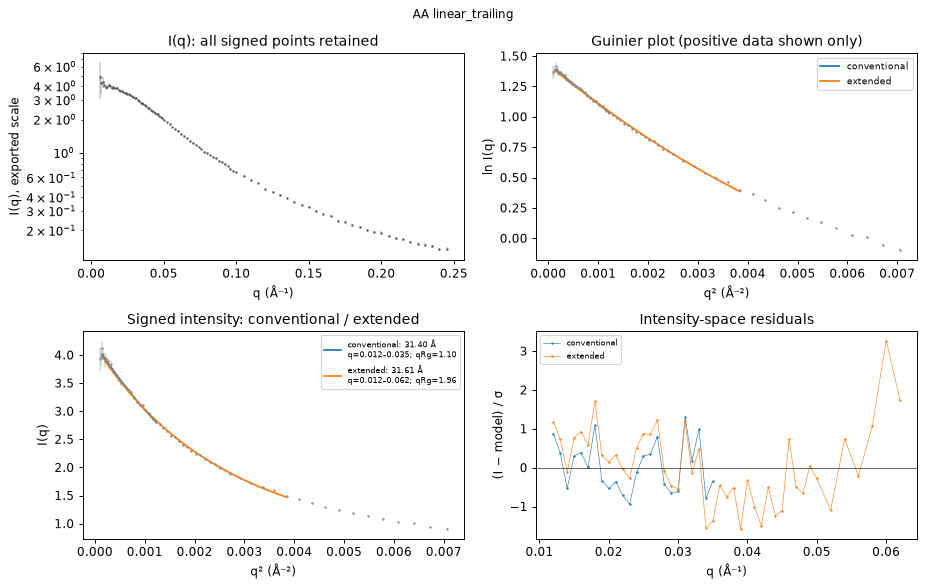

Component identity and physical validity are not established by a converged fit.

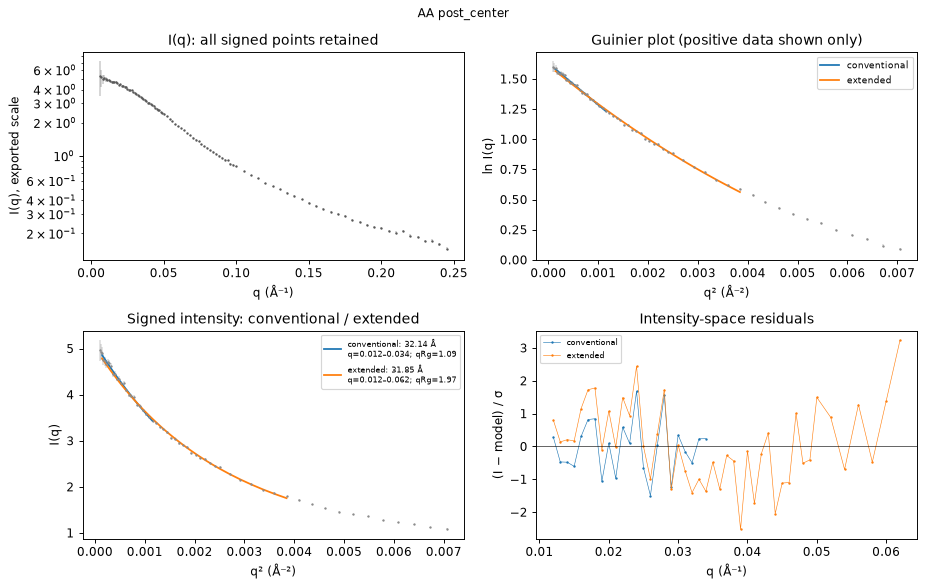

Component identity and physical validity are not established by a converged fit.

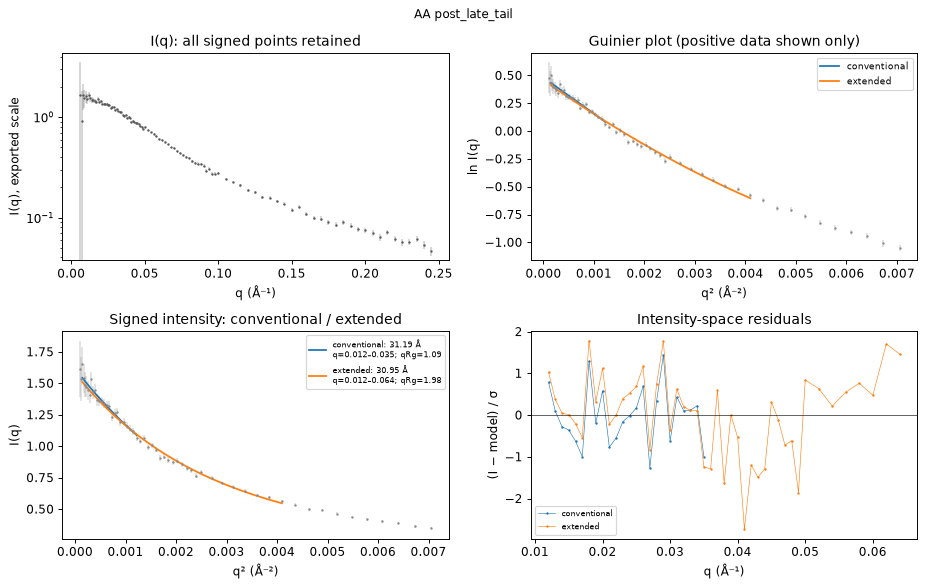

Component identity and physical validity are not established by a converged fit.

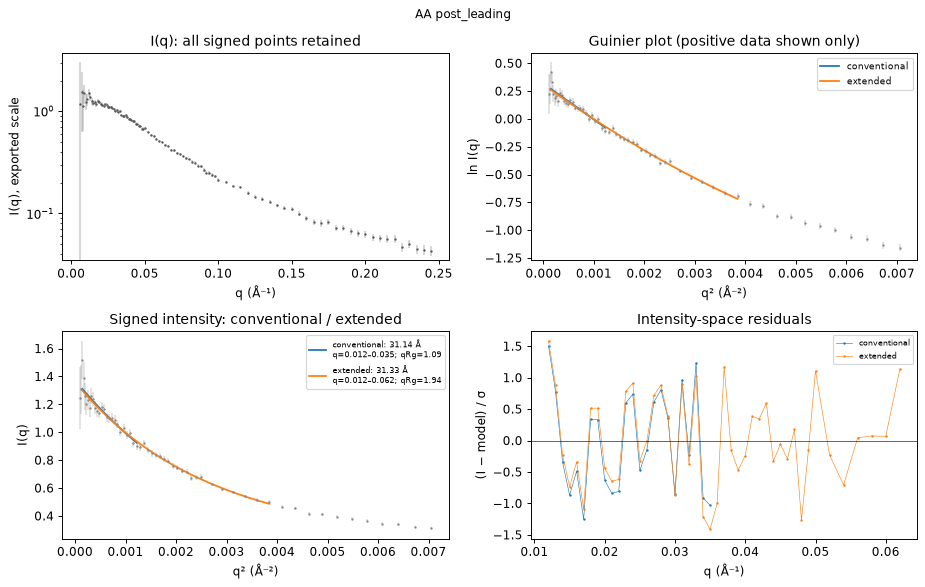

Component identity and physical validity are not established by a converged fit.

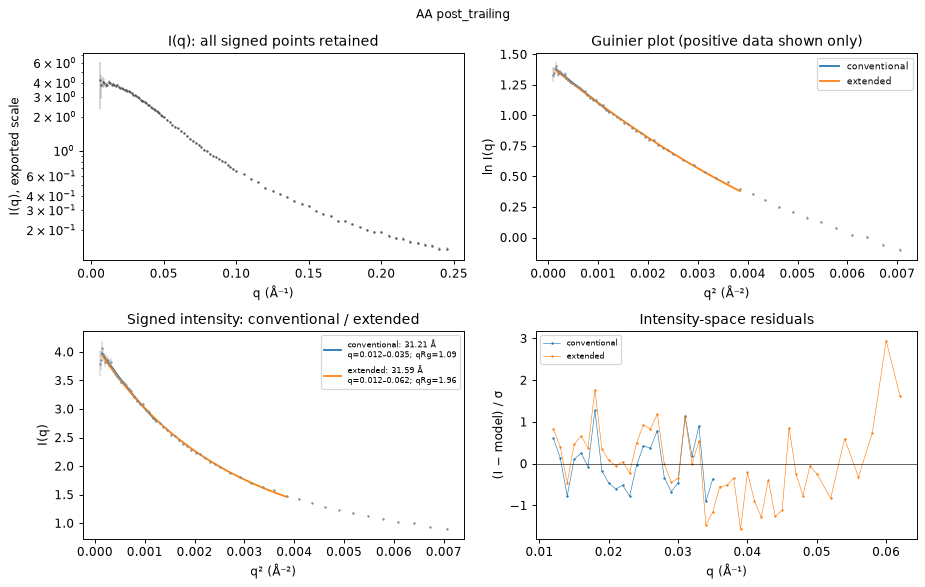

Component identity and physical validity are not established by a converged fit.

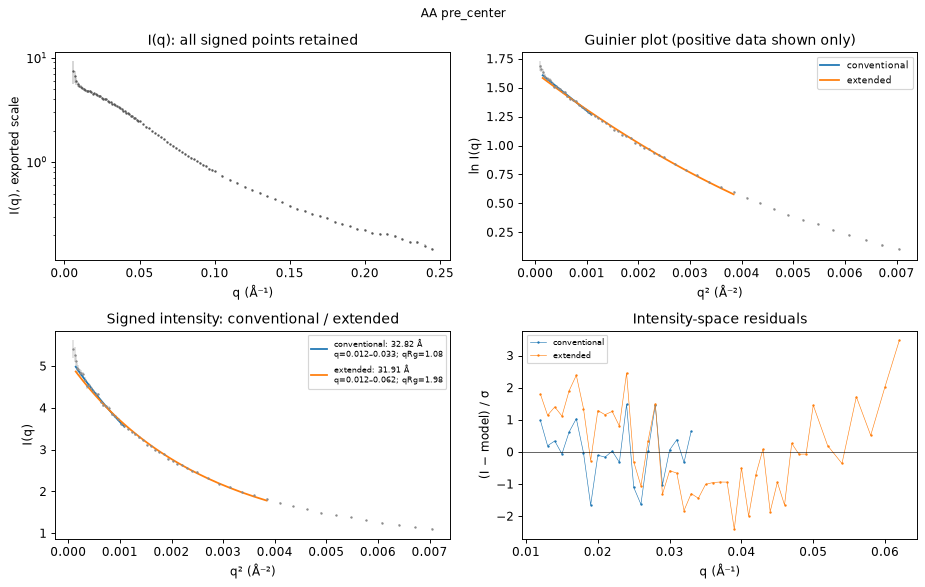

Component identity and physical validity are not established by a converged fit. Extended residual chi-square/dof >2.

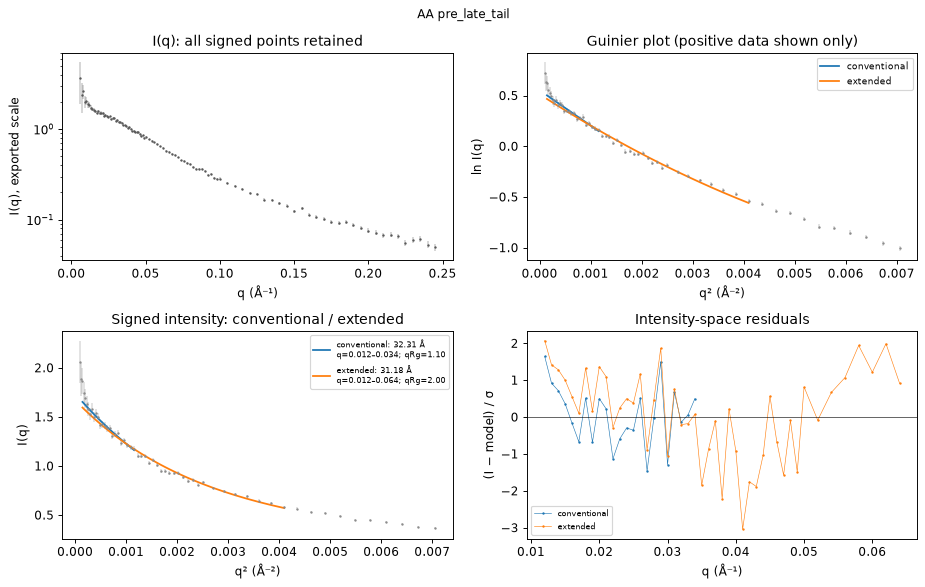

Component identity and physical validity are not established by a converged fit.

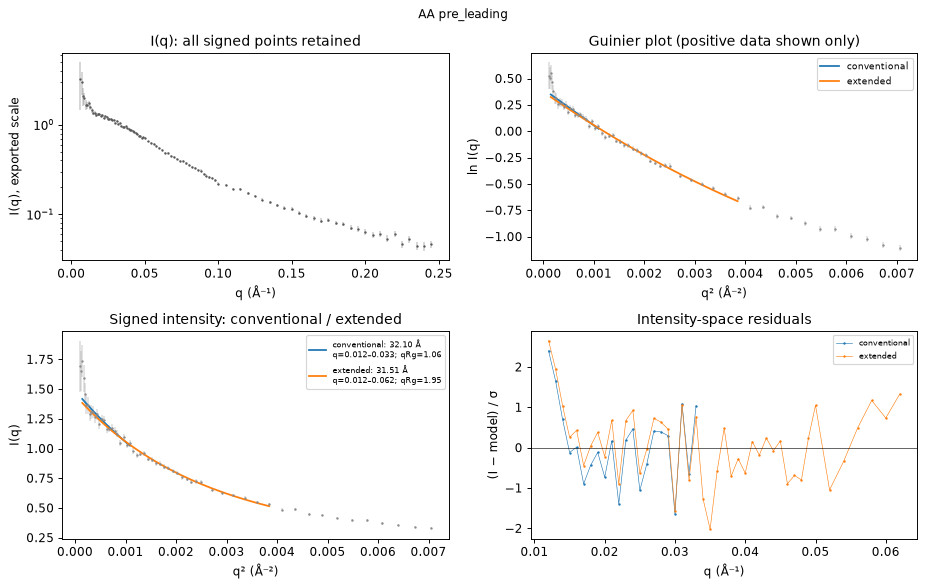

Component identity and physical validity are not established by a converged fit.

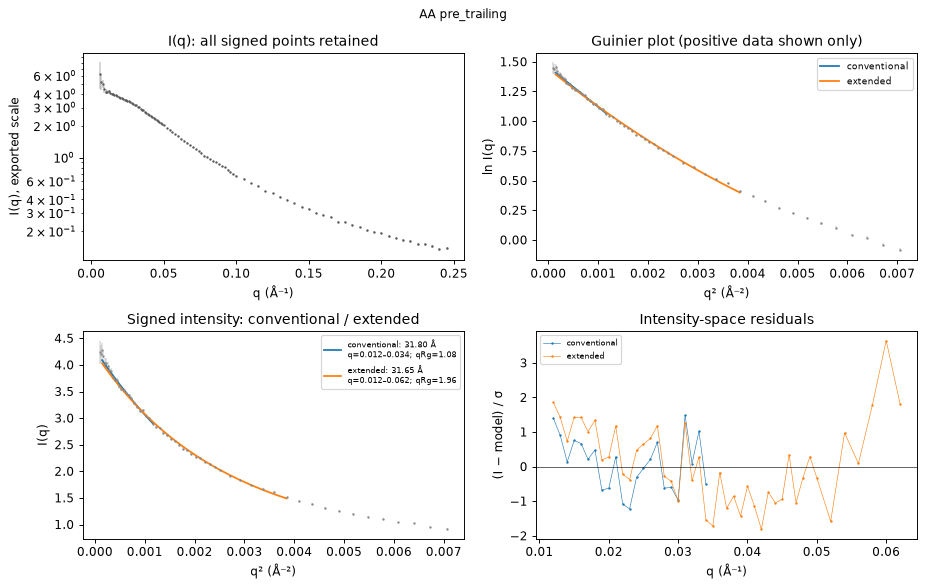

Component identity and physical validity are not established by a converged fit.

| Curve | Conventional Rg ± SE (Å) | Extended, same q range | Extended, qRg≤2 | Conditional extended 95% |
|---|---:|---:|---:|---|
|WT linear_center|26.78 ± 0.42|27.68 ± 0.48|26.59 ± 0.14|[26.34, 26.87]|
|WT linear_late_tail|29.91 ± 2.40|30.25 ± 2.85|25.70 ± 0.58|[24.62, 26.97]|
|WT linear_leading|30.79 ± 1.36|31.59 ± 1.62|29.51 ± 0.42|[28.71, 30.23]|
|WT linear_trailing|26.55 ± 0.60|27.39 ± 0.69|26.13 ± 0.19|[25.78, 26.52]|
|WT post_center|25.57 ± 0.41|26.39 ± 0.47|26.13 ± 0.15|[25.87, 26.42]|
|WT post_late_tail|25.45 ± 1.84|25.76 ± 2.13|24.61 ± 0.59|[23.51, 25.68]|
|WT post_leading|26.80 ± 1.20|27.36 ± 1.39|28.21 ± 0.43|[27.4, 29.01]|
|WT post_trailing|25.50 ± 0.64|26.23 ± 0.72|25.60 ± 0.20|[25.23, 26.0]|
|WT pre_center|28.19 ± 0.45|29.20 ± 0.53|27.29 ± 0.15|[27.0, 27.55]|
|WT pre_late_tail|45.51 ± 8.83|47.41 ± 10.55|31.04 ± 0.73|[29.49, 32.61]|
|WT pre_leading|48.93 ± 4.23|51.52 ± 5.52|31.20 ± 0.45|[30.28, 32.09]|
|WT pre_trailing|29.32 ± 0.72|30.40 ± 0.84|27.28 ± 0.21|[26.87, 27.66]|
|AA linear_center|32.33 ± 0.35|33.72 ± 0.41|31.87 ± 0.11|[31.67, 32.09]|
|AA linear_late_tail|31.08 ± 1.03|32.21 ± 1.20|31.01 ± 0.28|[30.46, 31.55]|
|AA linear_leading|31.34 ± 1.16|32.42 ± 1.35|31.41 ± 0.34|[30.76, 32.07]|
|AA linear_trailing|31.40 ± 0.39|32.71 ± 0.46|31.61 ± 0.13|[31.36, 31.85]|
|AA post_center|32.14 ± 0.37|33.49 ± 0.44|31.85 ± 0.11|[31.63, 32.07]|
|AA post_late_tail|31.19 ± 0.99|32.38 ± 1.16|30.95 ± 0.30|[30.37, 31.52]|
|AA post_leading|31.14 ± 1.16|32.24 ± 1.36|31.33 ± 0.37|[30.64, 32.05]|
|AA post_trailing|31.21 ± 0.41|32.48 ± 0.48|31.59 ± 0.13|[31.33, 31.84]|
|AA pre_center|32.82 ± 0.39|34.22 ± 0.46|31.91 ± 0.11|[31.7, 32.12]|
|AA pre_late_tail|32.31 ± 0.96|33.68 ± 1.15|31.18 ± 0.28|[30.63, 31.71]|
|AA pre_leading|32.10 ± 1.24|33.20 ± 1.47|31.51 ± 0.34|[30.85, 32.19]|
|AA pre_trailing|31.80 ± 0.42|33.12 ± 0.50|31.65 ± 0.13|[31.41, 31.9]|


In [2]:
from pathlib import Path
import sys,json,numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd()
if not (ROOT/'analysis/compare_all_iq.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from compare_all_iq import *
%matplotlib inline

_all=json.loads((OUT/'fit_results.json').read_text())
comparison_rows=gallery(_all,['Non-EFA window and baseline'])

## Kratky comparisons
Raw: q²I(q) versus q. I(0)-normalized: q²I(q)/I(0) versus q. Dimensionless: (qRg)²I(q)/I(0) versus qRg. Conventional and extended Guinier normalizations are shown separately; extended curves use the measured I(q), not an extrapolation of the extended Guinier model to high q.

Raw component scales can differ. Multiplication by q² amplifies high-q noise and residual backgrounds; apparent differences there are not automatically structural. Dimensionless normalization can hide absolute size differences, so read these alongside the Rg comparison. Kratky shape does not determine oligomer identity. [RAW Kratky documentation](https://bioxtas-raw.readthedocs.io/en/v2.3.1/tutorial/s1_kratky.html).

Pointwise95% bands: each intensity perturbation refits both Rg and I(0), preserving their dependence on that same curve. Interpolation at fixed qRg includes uncertainty in horizontal scaling; no extrapolation and no band where fewer than80% of draws cover the grid. Existing EFA perturbations are reused for main/average. Other curves assume independent q errors. These are conditional bands, not simultaneous confidence regions or tests of differences between correlated curves; baseline, support and fit-range choices remain additional uncertainty. Raw bands use±1.96q²sigma. Unsupported normalizations are explicitly omitted, while their signed raw Kratky curves remain visible.


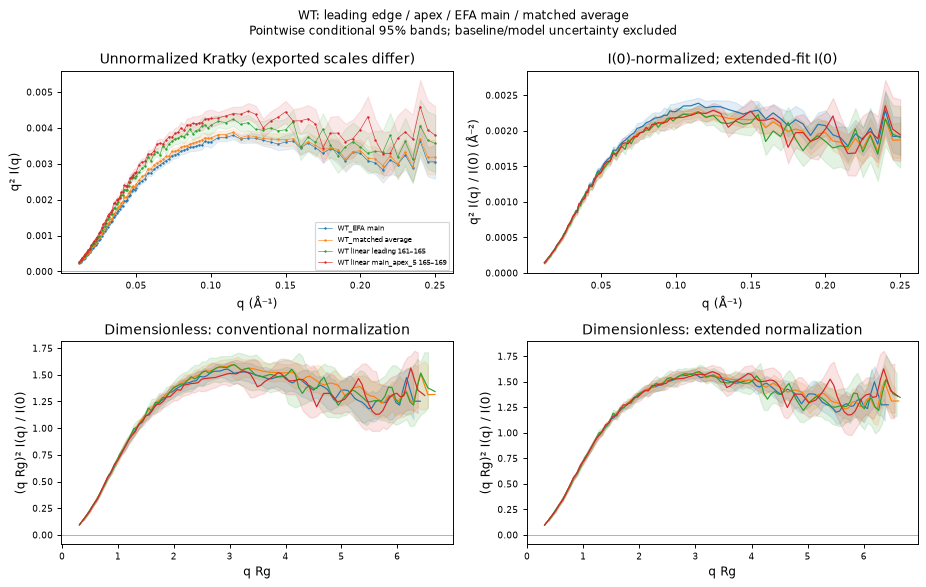

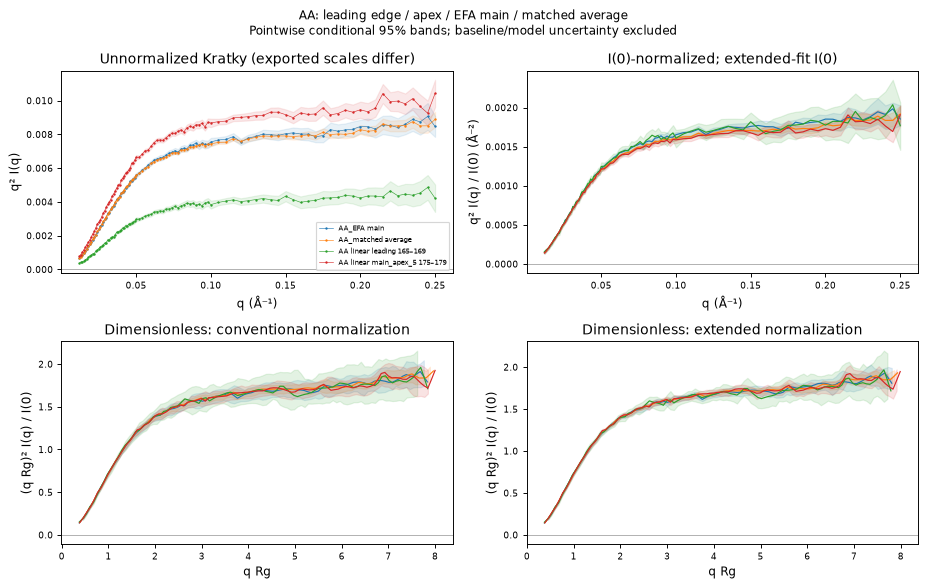

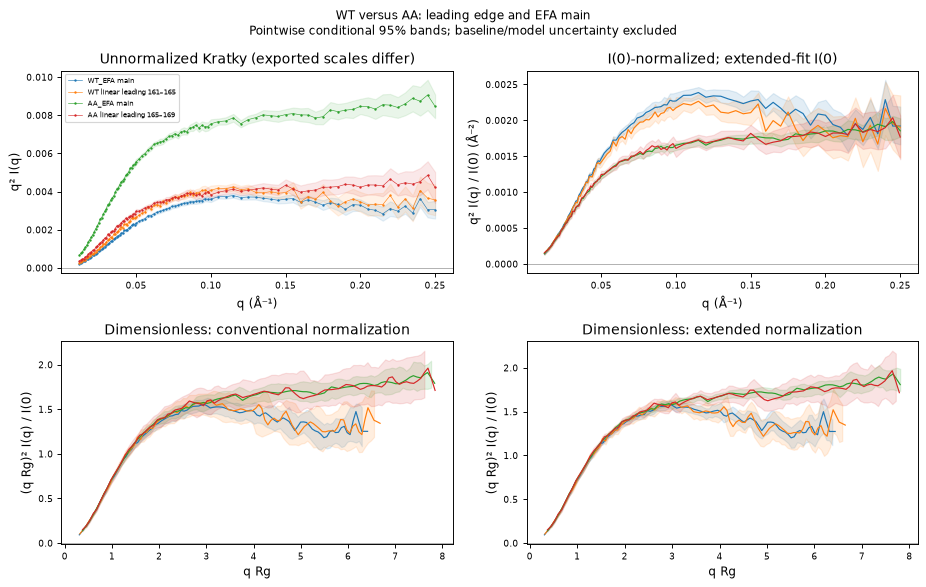

In [1]:
from pathlib import Path
import sys,json
ROOT=Path.cwd()
if not (ROOT/'analysis/kratky_comparison.py').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'analysis'))
from kratky_comparison import *
%matplotlib inline

if not (KOUT/'metadata.json').exists(): build_kratky_cache(n=200)
priority_kratky()